# Sustentación integral y reproducible desde la tabla maestra

## Caso SportRetail LAM

> **Dashboard publicado:** [abrir la experiencia interactiva en GitHub Pages](https://juancamiloguerra.github.io/adidas-dest-ac/). No requiere ejecutar Python ni este notebook.

Este notebook es la pieza central para explicar el proyecto **desde la tabla consolidada `orders_enriched` hasta la etapa inmediatamente anterior al dashboard**. Reproduce los controles de calidad, las decisiones de limpieza, la analítica comercial, los contrastes estadísticos, los escenarios de datos faltantes y la segmentación oficial de clientes construida en el repositorio.

### Pregunta de negocio

¿Cómo está funcionando SportRetail LAM, dónde se concentran el valor bruto de pedidos y los riesgos, qué clientes y productos explican el desempeño y qué acciones pueden proponerse sin exceder la evidencia disponible?

### Alcance y fronteras

- **Punto de partida:** la tabla maestra ya consolidada, no los archivos originales del proveedor.
- **Artefactos válidos:** únicamente archivos construidos dentro de este repositorio: CSV, Parquet, SQLite, reportes de calidad, resultados analíticos, documentación y modelo.
- **Fuera de alcance:** llamadas a la API, reconstrucción de la extracción y construcción o explicación del dashboard.
- **Dos modelos con funciones distintas:** Random Forest es un experimento complementario para estimar `quantity` nula; la segmentación jerárquica es el modelo oficial de Machine Learning del proyecto.

### Principio metodológico

Un dato nulo, extremo o ambiguo no se corrige por intuición. Se conserva el valor fuente, se cuantifica su impacto, se construyen alternativas separadas cuando aportan valor y se explicita qué es observación, derivación, estimación o recomendación.

## 0. Ruta de la sustentación y trazabilidad con el requerimiento

El recorrido responde al requerimiento inicial con una secuencia verificable:

`tabla consolidada → persistencia → esquema y calidad → nulos y escenarios → reglas derivadas → precios y outliers → KPIs y análisis comercial → cancelaciones e inferencia → segmentación oficial → hallazgos y recomendaciones`

| Requerimiento posterior a la consolidación | Secciones del notebook | Artefactos construidos que se verifican |
|---|---:|---|
| Persistir y reconciliar la tabla | 2.1 | `orders_enriched.csv`, `.parquet`, `sportretail.db`, `persistence_validation.json` |
| Calidad, limpieza y trazabilidad | 3–11 | `data_quality_report.csv`, `cleaning_decisions.md` |
| KPIs y análisis del negocio | 12–14 | `business_summary.json`, `executive_summary.md` |
| Productos, clientes y concentración | 14–15 | tabla maestra y resultados reproducidos |
| Riesgo de cancelación e inferencia | 16–19 | análisis reproducido a nivel pedido |
| Machine Learning defendible | 20 | `outputs/model/` y `outputs/quantity_model/`: segmentación oficial y escenario experimental |
| Hallazgos y acciones | 21–23 | reportes ejecutivos y conclusiones reproducidas |

La granularidad se cambia deliberadamente cuando corresponde: línea para productos y revenue; pedido para estados y ticket; cliente para segmentación. Esta distinción evita duplicar pedidos o interpretar líneas como clientes independientes.

## 1. Preparación del entorno analítico

Se importan bibliotecas para manipulación, visualización estática y estadística. `scikit-learn` se utiliza en dos contextos claramente separados: el Random Forest experimental de la sección 5.3 y la reproducción de la segmentación oficial en la sección 20.

Las rutas son relativas al repositorio y las semillas se fijan donde existe aleatoriedad. Así, una tercera persona puede abrir el proyecto en Visual Studio Code, ejecutar todas las celdas y contrastar los resultados con los artefactos versionados.

In [1]:
# Path permite construir rutas que funcionan en Windows, macOS o Linux.
from pathlib import Path

# Bibliotecas principales de análisis.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pruebas estadísticas que usaremos más adelante.
from scipy import stats
from IPython.display import display

# Configuración para que pandas muestre tablas amplias y números legibles.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Estilo sencillo para los gráficos del notebook.
plt.style.use("seaborn-v0_8-whitegrid")

print("Entorno preparado correctamente.")

Entorno preparado correctamente.


## 2. Localización y carga de la tabla maestra

La fuente analítica es `data/processed/orders_enriched.csv`. El código admite que el kernel se inicie desde la raíz del proyecto o desde `notebooks`, evitando rutas personales y haciendo el ejercicio portable.

El CSV se carga con `low_memory=False` para que Pandas evalúe las columnas de forma consistente. La fecha del pedido se convierte explícitamente a tipo temporal; si una fecha no puede interpretarse, queda marcada como ausente para su posterior control.

En esta etapa no se transforma el contenido: primero se confirma que el archivo exista, se carga y se conserva una copia de trabajo en `df`.


In [2]:
# VS Code puede iniciar el notebook desde la raíz del proyecto o desde /notebooks.
current_path = Path.cwd()

if (current_path / "data" / "processed" / "orders_enriched.csv").exists():
    project_root = current_path
elif (current_path.parent / "data" / "processed" / "orders_enriched.csv").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError(
        "No se encontró data/processed/orders_enriched.csv. "
        "Abra el proyecto adidas-dest-ac en VS Code y vuelva a ejecutar."
    )

data_path = project_root / "data" / "processed" / "orders_enriched.csv"

# parse_dates convierte order_date desde texto a fecha de pandas.
df = pd.read_csv(data_path, parse_dates=["order_date"], low_memory=False)

print(f"Archivo: {data_path}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

Archivo: C:\Users\juanc\Documents\adidas-dest-ac\data\processed\orders_enriched.csv
Filas: 733
Columnas: 48


### 2.1 Reconciliación de los formatos construidos por el proyecto

El requerimiento exigía persistir la tabla en CSV, Parquet y SQLite y comprobar que los tres formatos conservaran los mismos totales. Esta validación no vuelve a la API: compara exclusivamente los productos finales construidos por el ETL.

Se contrastan filas, columnas, suma de cantidades y suma de revenue. La fecha puede tener una representación física distinta entre formatos, por lo que la reconciliación se centra en contenido y métricas, no en exigir que CSV y Parquet tengan idéntico tipo de almacenamiento.

In [3]:
import json
import sqlite3
import importlib.util

processed_dir = project_root / "data" / "processed"
quality_dir = project_root / "data" / "quality"

with open(quality_dir / "persistence_validation.json", encoding="utf-8") as file:
    persistence_official = json.load(file)

# CSV y SQLite se validan directamente en el kernel actual.
df_csv_check = pd.read_csv(processed_dir / "orders_enriched.csv", low_memory=False)
with sqlite3.connect(processed_dir / "sportretail.db") as connection:
    sqlite_metrics = pd.read_sql_query(
        """
        SELECT COUNT(*) AS filas,
               COUNT(*) - COUNT(quantity) AS quantity_nula,
               SUM(quantity) AS suma_quantity,
               SUM(revenue) AS suma_revenue
        FROM orders_enriched
        """,
        connection,
    ).iloc[0]
    sqlite_indexes = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type = 'index' ORDER BY name",
        connection,
    )

# Parquet requiere pyarrow o fastparquet. Si el kernel no los tiene, se usa el
# reporte de reconciliación creado al persistir la tabla y comprobamos el archivo.
parquet_path = processed_dir / "orders_enriched.parquet"
assert parquet_path.exists() and parquet_path.stat().st_size > 0
parquet_engine_available = any(
    importlib.util.find_spec(engine) is not None for engine in ("pyarrow", "fastparquet")
)
if parquet_engine_available:
    df_parquet_check = pd.read_parquet(parquet_path)
    parquet_metrics = {
        "filas": len(df_parquet_check), "columnas": df_parquet_check.shape[1],
        "suma_quantity": df_parquet_check["quantity"].sum(),
        "suma_revenue": df_parquet_check["revenue"].sum(),
    }
    parquet_method = "lectura directa"
else:
    parquet_metrics = {
        "filas": persistence_official["rows"], "columnas": persistence_official["columns"],
        "suma_quantity": persistence_official["quantity_sum"],
        "suma_revenue": persistence_official["revenue_sum"],
    }
    parquet_method = "reporte oficial de persistencia (kernel sin motor Parquet)"

reconciliation = pd.DataFrame([
    {"formato": "CSV", "método": "lectura directa", "filas": len(df_csv_check),
     "columnas": df_csv_check.shape[1], "suma_quantity": df_csv_check["quantity"].sum(),
     "suma_revenue": df_csv_check["revenue"].sum()},
    {"formato": "Parquet", "método": parquet_method, **parquet_metrics},
    {"formato": "SQLite", "método": "consulta SQL directa", "filas": int(sqlite_metrics["filas"]),
     "columnas": persistence_official["columns"], "suma_quantity": sqlite_metrics["suma_quantity"],
     "suma_revenue": sqlite_metrics["suma_revenue"]},
])

display(reconciliation)
display(sqlite_indexes)

assert reconciliation["filas"].nunique() == 1
assert reconciliation["columnas"].nunique() == 1
assert np.allclose(reconciliation["suma_quantity"], persistence_official["quantity_sum"])
assert np.allclose(reconciliation["suma_revenue"], persistence_official["revenue_sum"])

print("Reconciliación aprobada: los tres formatos representan la misma tabla maestra.")

,formato,método,filas,columnas,suma_quantity,suma_revenue
0,CSV,lectura directa,733,48,"45,414.00","4,174,258.92"
1,Parquet,lectura directa,733,48,"45,414.00","4,174,258.92"
2,SQLite,consulta SQL directa,733,48,"45,414.00","4,174,258.92"


,name
0,idx_orders_category
1,idx_orders_channel
2,idx_orders_country
3,idx_orders_order_date
4,idx_orders_order_id
5,idx_orders_product_id
6,idx_orders_user_id


Reconciliación aprobada: los tres formatos representan la misma tabla maestra.


**Conclusión 2.1.** Los tres formatos contienen 733 líneas y 48 columnas, con 45.414 unidades observadas y revenue conocido de 4.174.258,92. SQLite incluye índices analíticos para acelerar consultas por pedido, cliente, producto, fecha, país, categoría y canal. La persistencia no introdujo pérdida ni duplicación de información.

### 2.2 Reporte oficial de calidad construido por el proyecto

Además de volver a calcular controles en las secciones siguientes, se lee el reporte oficial generado por `src/data_quality.py`. Esto alinea la sustentación con la lógica reutilizable del repositorio y permite distinguir una regla formal de una exploración puntual del notebook.

In [4]:
quality_report_official = pd.read_csv(quality_dir / "data_quality_report.csv")

# Primero se muestran las reglas con registros afectados y se conserva el reporte completo.
quality_affected = quality_report_official.loc[
    quality_report_official["registros_afectados"].gt(0)
].sort_values(["severidad", "porcentaje_afectado"], ascending=[True, False])

display(quality_affected)
print(f"Reglas evaluadas: {len(quality_report_official)}")
print(f"Reglas con alguna afectación: {len(quality_affected)}")

,regla_evaluada,registros_revisados,registros_afectados,porcentaje_afectado,accion_aplicada,justificacion,severidad
2,Cantidad nula,733,12,1.64,Conservar; revenue queda nulo,Imputar cantidad inventaría ventas no observadas.,Alta
16,Calificación nula,733,18,2.46,Conservar nulo,No se inventa percepción de producto.,Baja
15,Inventario nulo,733,8,1.09,Conservar nulo,No afecta el cálculo histórico del valor bruto...,Baja
13,Revenue extremo por IQR,733,44,6.00,Conservar y monitorear,"En mayoristas, valores altos pueden ser compra...",Media


Reglas evaluadas: 18
Reglas con alguna afectación: 4


**Conclusión 2.2.** Las afectaciones materiales son 12 cantidades nulas, 44 revenues extremos por IQR, 8 inventarios nulos y 18 calificaciones nulas. No existen claves faltantes, líneas duplicadas, precios no positivos, dominios inválidos ni fallos de correspondencia. Ninguna regla justifica borrar filas automáticamente; por eso se conservan flags y escenarios auditables.

## 3. Granularidad y unidad de análisis

La tabla contiene una fila por **línea de pedido**, no una fila por pedido. La clave lógica esperada es:

`order_id + line_number + product_id`

Esta distinción cambia la interpretación de los cálculos:

- sumar `revenue` o `quantity` a nivel de línea es válido;
- contar filas no equivale a contar pedidos;
- para contar pedidos se utiliza `order_id.nunique()`;
- para estudiar cancelaciones se construirá posteriormente una tabla con una fila por pedido.

Antes de continuar se muestran las primeras 15 filas y las 48 columnas, de modo que la sustentación parta de la evidencia observable y no de una descripción abstracta.


In [5]:
# muestreo,primeras 15 líneas con todas las columnas.
display(df.head(10))

print(f"Líneas de pedido: {len(df):,}")
print(f"Pedidos únicos: {df['order_id'].nunique():,}")
print(f"Productos únicos: {df['product_id'].nunique():,}")
print(f"Clientes únicos: {df['user_id'].nunique():,}")

,order_id,user_id,order_date,order_status,channel,reported_total_products,line_number,product_id,line_product_name,line_category,unit_price,quantity,line_discount_percentage,catalog_product_name,category,brand,catalog_price,catalog_discount_percentage,inventory,rating,reviews,sku,catalog_duplicate_flag,age,country,city,retailer_type,customer_name,product_name,country_original,channel_original,status_original,discount_percentage,revenue,price_segment,year,quarter,month,month_name,year_month,delivered_flag,canceled_flag,product_match_flag,user_match_flag,price_difference,price_difference_pct,data_quality_flag,valid_sales_flag
0,1,65,2024-12-03,delivered,Direct Sales,2,1,8,CoreFit Basketball Shoes v3,Footwear,91.60,18.00,8.90,CoreFit Basketball Shoes v3,Footwear,CoreFit,91.60,8.90,343.00,3.20,709,SR-FOO-0008,False,47,Argentina,Tucumán,Department Store,Josefina Duarte,CoreFit Basketball Shoes v3,Argentina,Direct Sales,delivered,8.90,"1,648.80",Medio,2024,4,12,Diciembre,2024-12,1,0,True,True,0.00,0.00,OK,True
1,1,65,2024-12-03,delivered,Direct Sales,2,2,58,AthletX Sports Bra v3,Apparel,87.71,112.00,7.50,AthletX Sports Bra v3,Apparel,AthletX,87.71,7.50,280.00,4.60,321,SR-APP-0058,False,47,Argentina,Tucumán,Department Store,Josefina Duarte,AthletX Sports Bra v3,Argentina,Direct Sales,delivered,7.50,"9,823.52",Medio,2024,4,12,Diciembre,2024-12,1,0,True,True,0.00,0.00,OK,True
2,2,6,2024-06-10,shipped,Distributor,2,1,91,CoreFit Resistance Bands v1,Equipment,36.90,61.00,18.00,CoreFit Resistance Bands v1,Equipment,CoreFit,36.90,18.00,161.00,2.80,558,SR-EQU-0091,False,30,Chile,Valparaíso,Independent,Roxana Jara,CoreFit Resistance Bands v1,Chile,Distributor,shipped,18.00,"2,250.90",Económico,2024,2,6,Junio,2024-06,0,0,True,True,0.00,0.00,OK,True
3,2,6,2024-06-10,shipped,Distributor,2,2,57,CoreFit Sports Bra v2,Apparel,64.26,83.00,7.40,CoreFit Sports Bra v2,Apparel,CoreFit,64.26,7.40,65.00,3.00,690,SR-APP-0057,False,30,Chile,Valparaíso,Independent,Roxana Jara,CoreFit Sports Bra v2,Chile,Distributor,shipped,7.40,"5,333.58",Medio,2024,2,6,Junio,2024-06,0,0,True,True,0.00,0.00,OK,True
4,3,87,2024-06-03,delivered,Direct Sales,5,1,7,SportRetail Pro Basketball Shoes v2,Footwear,203.78,13.00,19.30,SportRetail Pro Basketball Shoes v2,Footwear,SportRetail Pro,203.78,19.30,40.00,4.60,113,SR-FOO-0007,False,54,Chile,Santiago,Superstore,Karina Ibarra,SportRetail Pro Basketball Shoes v2,Chile,Direct Sales,delivered,19.30,"2,649.14",Premium,2024,2,6,Junio,2024-06,1,0,True,True,0.00,0.00,OK,True
5,3,87,2024-06-03,delivered,Direct Sales,5,2,102,CoreFit Yoga Mat v2,Equipment,89.84,76.00,15.60,CoreFit Yoga Mat v2,Equipment,CoreFit,89.84,15.60,338.00,4.50,212,SR-EQU-0102,False,54,Chile,Santiago,Superstore,Karina Ibarra,CoreFit Yoga Mat v2,Chile,Direct Sales,delivered,15.60,"6,827.84",Medio,2024,2,6,Junio,2024-06,1,0,True,True,0.00,0.00,OK,True
6,3,87,2024-06-03,delivered,Direct Sales,5,3,81,PowerEdge Gym Bag v1,Accessories,29.43,41.00,17.40,PowerEdge Gym Bag v1,Accessories,PowerEdge,29.43,17.40,154.00,4.60,624,SR-ACC-0081,False,54,Chile,Santiago,Superstore,Karina Ibarra,PowerEdge Gym Bag v1,Chile,Direct Sales,delivered,17.40,"1,206.63",Económico,2024,2,6,Junio,2024-06,1,0,True,True,0.00,0.00,OK,True
7,3,87,2024-06-03,delivered,Direct Sales,5,4,83,SpeedMax Gym Bag v3,Accessories,75.79,114.00,2.60,SpeedMax Gym Bag v3,Accessories,SpeedMax,75.79,2.60,491.00,3.40,480,SR-ACC-0083,False,54,Chile,Santiago,Superstore,Karina Ibarra,SpeedMax Gym Bag v3,Chile,Direct Sales,delivered,2.60,"8,640.06",Medio,2024,2,6,Junio,2024-06,1,0,True,True,0.00,0.00,OK,True
8,3,87,2024-06-03,delivered,Direct Sales,5,5,43,CoreFit Track Jacket v3,Apparel,24.85,82.00,8.30,CoreFit Track Jacket v3,Apparel,CoreFit,24.85,8.30,66.00,4.10,278,SR-APP-0043,False,54,Chile,Santiago,Superstore,Karina Ibarra,CoreFit Track Jacket v3,Chile,Direct Sales,delivered,8.30,"2,037.70",Económico,2024,2,6,Junio,2024-06,1,0,True,True,0.00,0.00,OK,True
9,4,45,2024-11-26,shipped,Direct Sales,3,1,84,PowerEdge Gym Bag v

Líneas de pedido: 733
Pedidos únicos: 200
Productos únicos: 120
Clientes únicos: 85


## 4. Linaje de las columnas

La tabla maestra integra tres conjuntos de datos y agrega variables analíticas:

- **pedido y línea:** identificadores, fecha, estado, canal, precio histórico, cantidad y descuento informado;
- **catálogo de productos:** nombre, categoría, marca, SKU, precio de catálogo, inventario, rating y reseñas;
- **usuario o minorista:** edad, país, ciudad y tipo de minorista;
- **variables derivadas:** `revenue`, `price_segment`, componentes temporales, diferencias de precio y flags de calidad.

El precio histórico se toma de la línea del pedido; no se reemplaza automáticamente por el precio actual del catálogo. Esta decisión conserva la trazabilidad de la transacción.

Los campos de contacto —correo, teléfono y dirección— se excluyeron por minimización de datos. No son necesarios para responder las preguntas analíticas de esta sustentación.


In [6]:
# Organizamos nombres de columnas para leer la tabla por familias.
column_families = {
    "pedido_y_linea": [
        "order_id", "user_id", "order_date", "order_status", "channel",
        "reported_total_products", "line_number", "product_id",
        "line_product_name", "line_category", "unit_price", "quantity",
        "line_discount_percentage",
    ],
    "catalogo_producto": [
        "catalog_product_name", "category", "brand", "catalog_price",
        "catalog_discount_percentage", "inventory", "rating", "reviews", "sku",
        "catalog_duplicate_flag",
    ],
    "usuario_minorista": [
        "age", "country", "city", "retailer_type", "customer_name",
    ],
    "derivadas_y_calidad": [
        "product_name", "country_original", "channel_original", "status_original",
        "discount_percentage", "revenue", "price_segment", "year", "quarter",
        "month", "month_name", "year_month", "delivered_flag", "canceled_flag",
        "product_match_flag", "user_match_flag", "price_difference",
        "price_difference_pct", "data_quality_flag", "valid_sales_flag",
    ],
}

for family, columns in column_families.items():
    print(f"\n{family.upper()} ({len(columns)} columnas)")
    print(columns)


PEDIDO_Y_LINEA (13 columnas)
['order_id', 'user_id', 'order_date', 'order_status', 'channel', 'reported_total_products', 'line_number', 'product_id', 'line_product_name', 'line_category', 'unit_price', 'quantity', 'line_discount_percentage']

CATALOGO_PRODUCTO (10 columnas)
['catalog_product_name', 'category', 'brand', 'catalog_price', 'catalog_discount_percentage', 'inventory', 'rating', 'reviews', 'sku', 'catalog_duplicate_flag']

USUARIO_MINORISTA (5 columnas)
['age', 'country', 'city', 'retailer_type', 'customer_name']

DERIVADAS_Y_CALIDAD (20 columnas)
['product_name', 'country_original', 'channel_original', 'status_original', 'discount_percentage', 'revenue', 'price_segment', 'year', 'quarter', 'month', 'month_name', 'year_month', 'delivered_flag', 'canceled_flag', 'product_match_flag', 'user_match_flag', 'price_difference', 'price_difference_pct', 'data_quality_flag', 'valid_sales_flag']


## 5. Auditoría del esquema y tratamiento de datos nulos

Antes de calcular indicadores se revisan tipos, valores únicos y ausencias. Un tipo incorrecto puede invalidar operaciones posteriores: una fecha almacenada como texto no se ordena cronológicamente de manera confiable y un número almacenado como cadena no puede agregarse correctamente.

El reporte de esquema permite responder cuatro preguntas por columna:

1. ¿qué tipo de dato tiene?;
2. ¿cuántos valores faltan?;
3. ¿qué porcentaje representan?;
4. ¿cuántos valores distintos existen?

El tratamiento de nulos se divide en tres partes: revisión visual, escenarios jerárquicos y una alternativa experimental con Random Forest.


In [7]:
schema_report = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "porcentaje_nulos": df.isna().mean().mul(100).round(2),
    "valores_unicos": df.nunique(dropna=True),
}).sort_values(["nulos", "valores_unicos"], ascending=[False, True])

display(schema_report)

,tipo,nulos,porcentaje_nulos,valores_unicos
rating,float64,18,2.46,25
quantity,float64,12,1.64,116
revenue,float64,12,1.64,698
inventory,float64,8,1.09,103
catalog_duplicate_flag,bool,0,0.00,1
year,int64,0,0.00,1
product_match_flag,bool,0,0.00,1
user_match_flag,bool,0,0.00,1
price_difference,float64,0,0.00,1
price_difference_pct,float64,0,0.00,1


### 5.1 Revisión visual de los datos nulos

No todos los nulos tienen el mismo significado. En la tabla aparecen principalmente en `quantity`, `revenue`, `inventory` y `rating`:

- `quantity` es un dato transaccional crítico;
- `revenue` queda nulo cuando falta `quantity`, porque depende de ella;
- `inventory` es un atributo de catálogo y nulo no significa inventario cero;
- `rating` es opcional y nulo no equivale a una calificación de cero.

La siguiente vista conserva todas las columnas, filtra únicamente las filas con al menos una ausencia y resalta visualmente las celdas nulas. La tabla original no se modifica.


In [8]:
# %pip install Jinja2

In [9]:
# Se seleccionan las filas que tienen al menos un valor nulo
# en cualquiera de las columnas.
mascara_nulos = df.isna().any(axis=1)

# Se conservan todas las columnas.
tabla_con_nulos = df.loc[mascara_nulos].copy()

print(f"Filas totales: {len(df):,}")
print(f"Filas con algún dato nulo: {len(tabla_con_nulos):,}")
print(f"Columnas mostradas: {tabla_con_nulos.shape[1]}")

# Coloreamos únicamente las celdas que contienen valores nulos.
def colorear_nulos(valor):
    if pd.isna(valor):
        return (
            "background-color: #d62728;"
            "color: white;"
            "font-weight: bold;"
        )
    return ""

# Permitimos que Pandas muestre todas las columnas.
with pd.option_context(
    "display.max_columns", None,
    "display.width", None
):
    # Formatos para que los números sean más fáciles de leer.
    formatos = {}

# Identificadores y cantidades: sin decimales.
columnas_enteras = [
    "order_id",
    "user_id",
    "reported_total_products",
    "line_number",
    "product_id",
    "quantity",
    "inventory",
    "reviews",
    "year",
    "month",
    "delivered_flag",
    "canceled_flag",
]

for columna in columnas_enteras:
    if columna in tabla_con_nulos.columns:
        formatos[columna] = "{:,.0f}"

# Precios, valor bruto y diferencias monetarias: dos decimales.
columnas_monetarias = [
    "unit_price",
    "catalog_price",
    "revenue",
    "price_difference",
    "absolute_price_difference",
    "revenue_recalculated",
]

for columna in columnas_monetarias:
    if columna in tabla_con_nulos.columns:
        formatos[columna] = "{:,.2f}"

# Descuentos y porcentajes: un decimal y símbolo %.
columnas_porcentaje = [
    "line_discount_percentage",
    "catalog_discount_percentage",
    "discount_percentage",
    "percentage_price_difference",
]

for columna in columnas_porcentaje:
    if columna in tabla_con_nulos.columns:
        formatos[columna] = "{:.1f}%"

# Calificaciones: un decimal.
if "rating" in tabla_con_nulos.columns:
    formatos["rating"] = "{:.1f}"

# Fecha sin la hora 00:00:00.
if "order_date" in tabla_con_nulos.columns:
    formatos["order_date"] = lambda fecha: fecha.strftime("%Y-%m-%d")

# Se muestran todas las columnas y se resaltan los nulos.
with pd.option_context(
    "display.max_columns", None,
    "display.width", None
):
    display(
        tabla_con_nulos.style
            .map(colorear_nulos)
            .format(
                formatter=formatos,
                na_rep="NULO"
            )
    )



Filas totales: 733
Filas con algún dato nulo: 36
Columnas mostradas: 48


,order_id,user_id,order_date,order_status,channel,reported_total_products,line_number,product_id,line_product_name,line_category,unit_price,quantity,line_discount_percentage,catalog_product_name,category,brand,catalog_price,catalog_discount_percentage,inventory,rating,reviews,sku,catalog_duplicate_flag,age,country,city,retailer_type,customer_name,product_name,country_original,channel_original,status_original,discount_percentage,revenue,price_segment,year,quarter,month,month_name,year_month,delivered_flag,canceled_flag,product_match_flag,user_match_flag,price_difference,price_difference_pct,data_quality_flag,valid_sales_flag
26,7,47,2024-08-15,delivered,Distributor,6,4,79,UrbanSport Headband v4,Accessories,87.10,105,18.0%,UrbanSport Headband v4,Accessories,UrbanSport,87.10,18.0%,398,NULO,328,SR-ACC-0079,False,28,Colombia,Barranquilla,Department Store,Elvia Sandoval,UrbanSport Headband v4,Colombia,Distributor,delivered,18.0%,"9,145.50",Medio,"2,024",3,8,Agosto,2024-08,1,0,True,True,0.00,0.000000,Calificación nula,True
27,7,47,2024-08-15,delivered,Distributor,6,5,37,SpeedMax Training Shorts v2,Apparel,34.40,111,16.1%,SpeedMax Training Shorts v2,Apparel,SpeedMax,34.40,16.1%,234,NULO,779,SR-APP-0037,False,28,Colombia,Barranquilla,Department Store,Elvia Sandoval,SpeedMax Training Shorts v2,Colombia,Distributor,delivered,16.1%,"3,818.40",Económico,"2,024",3,8,Agosto,2024-08,1,0,True,True,0.00,0.000000,Calificación nula,True
43,11,98,2024-07-21,delivered,Distributor,6,3,79,UrbanSport Headband v4,Accessories,87.10,98,18.0%,UrbanSport Headband v4,Accessories,UrbanSport,87.10,18.0%,398,NULO,328,SR-ACC-0079,False,27,Perú,Lima,Superstore,Chita Rey,UrbanSport Headband v4,Perú,Distributor,delivered,18.0%,"8,535.80",Medio,"2,024",3,7,Julio,2024-07,1,0,True,True,0.00,0.000000,Calificación nula,True
52,13,31,2024-09-01,shipped,Distributor,6,5,79,UrbanSport Headband v4,Accessories,87.10,72,18.0%,UrbanSport Headband v4,Accessories,UrbanSport,87.10,18.0%,398,NULO,328,SR-ACC-0079,False,31,Perú,Trujillo,Superstore,Jesusa Hervia,UrbanSport Headband v4,Perú,Distributor,shipped,18.0%,"6,271.20",Medio,"2,024",3,9,Septiembre,2024-09,0,0,True,True,0.00,0.000000,Calificación nula,True
131,33,7,2024-07-05,delivered,E-commerce B2B,3,3,113,SportRetail Pro Training Gloves v3,Equipment,17.74,6,15.8%,SportRetail Pro Training Gloves v3,Equipment,SportRetail Pro,17.74,15.8%,409,NULO,172,SR-EQU-0113,False,54,Chile,Temuco,Sports Chain,Erasmo Mondaca,SportRetail Pro Training Gloves v3,Chile,E-commerce B2B,delivered,15.8%,106.44,Económico,"2,024",3,7,Julio,2024-07,1,0,True,True,0.00,0.000000,Calificación nula,True
173,43,90,2024-11-08,confirmed,Distributor,3,3,79,UrbanSport Headband v4,Accessories,87.10,120,18.0%,UrbanSport Headband v4,Accessories,UrbanSport,87.10,18.0%,398,NULO,328,SR-ACC-0079,False,34,Colombia,Cali,Sports Chain,Enrique Díaz,UrbanSport Headband v4,Colombia,Distributor,confirmed,18.0%,"10,452.00",Medio,"2,024",4,11,Noviembre,2024-11,0,0,True,True,0.00,0.000000,Calificación nula,True
186,47,65,2024-05-19,delivered,Direct Sales,4,1,35,AthletX Performance T-Shirt v5,Apparel,64.42,47,23.5%,AthletX Performance T-Shirt v5,Apparel,AthletX,64.42,23.5%,NULO,3.1,618,SR-APP-0035,False,47,Argentina,Tucumán,Department Store,Josefina Duarte,AthletX Performance T-Shirt v5,Argentina,Direct Sales,delivered,23.5%,"3,027.74",Medio,"2,024",2,5,Mayo,2024-05,1,0,True,True,0.00,0.000000,Inventario nulo,True
194,48,23,2024-07-08,shipped,Distributor,5,5,106,SportRetail Pro Foam Roller v1,Equipment,36.75,NULO,16.9%,SportRetail Pro Foam Roller v1,Equipment,SportRetail Pro,36.75,16.9%,440,3.9,31,SR-EQU-0106,False,50,Argentina,Córdoba,Sports Chain,Giuliana Garcia,SportRetail Pro Foam Roller v1,Argentina,Distributor,shipped,16.9%,NULO,Económico,"2,024",3,7,Julio,2024-07,0,0,True,True,0.00,0.000000,Cantidad nula,False
234,62,8,2024-07-14,confirmed,Distributor,5,2,113,SportRetail Pro Training Gloves v3,Equipment,17.74,76,15.8%,SportRetail Pro Training Gloves v3,Equipment,SportRetail

#### 5.1.1 Caso de trazabilidad: usuario 23 y pedido 48  (muestreo)

Para demostrar cómo se rastrea una ausencia, se revisa el historial completo del usuario 23. Este usuario tiene los pedidos 24 y 48; la quinta línea del pedido 48 contiene `quantity` nula para el producto 106.

El caso permite comprobar que:

- la ausencia ya viene desde la fuente;
- las demás líneas del pedido siguen siendo válidas;
- el subtotal conocido no debe presentarse como total completo;
- las compras del mismo usuario aportan contexto, pero no revelan la cantidad real faltante.


In [10]:
# ----- Muestreo de pedidos del usuario 23 -----

pedidos_usuario_23 = (
    df.loc[df["user_id"].eq(23)]
      .sort_values(
          by=["order_id", "line_number"],
          ascending=[True, True]
      )
      .copy()
)

pedidos_encontrados = (
    pedidos_usuario_23["order_id"]
    .drop_duplicates()
    .tolist()
)

print("Usuario: 23")
print(f"Pedidos encontrados: {pedidos_encontrados}")
print(f"Cantidad de pedidos: {pedidos_usuario_23['order_id'].nunique()}")
print(f"Cantidad total de líneas: {len(pedidos_usuario_23)}")
print(f"Productos diferentes: {pedidos_usuario_23['product_id'].nunique()}")

with pd.option_context(
    "display.max_columns", None,
    "display.width", None
):
    display(
        pedidos_usuario_23.style
            .map(colorear_nulos)
            .format(
                formatter=formatos,
                na_rep="NULO"
            )
    )

Usuario: 23
Pedidos encontrados: [24, 48]
Cantidad de pedidos: 2
Cantidad total de líneas: 8
Productos diferentes: 8


,order_id,user_id,order_date,order_status,channel,reported_total_products,line_number,product_id,line_product_name,line_category,unit_price,quantity,line_discount_percentage,catalog_product_name,category,brand,catalog_price,catalog_discount_percentage,inventory,rating,reviews,sku,catalog_duplicate_flag,age,country,city,retailer_type,customer_name,product_name,country_original,channel_original,status_original,discount_percentage,revenue,price_segment,year,quarter,month,month_name,year_month,delivered_flag,canceled_flag,product_match_flag,user_match_flag,price_difference,price_difference_pct,data_quality_flag,valid_sales_flag
93,24,23,2024-10-12,delivered,E-commerce B2B,3,1,66,UrbanSport Water Bottle v1,Accessories,44.14,30,22.7%,UrbanSport Water Bottle v1,Accessories,UrbanSport,44.14,22.7%,228,4.7,771,SR-ACC-0066,False,50,Argentina,Córdoba,Sports Chain,Giuliana Garcia,UrbanSport Water Bottle v1,Argentina,E-commerce B2B,delivered,22.7%,"1,324.20",Económico,"2,024",4,10,Octubre,2024-10,1,0,True,True,0.00,0.000000,OK,True
94,24,23,2024-10-12,delivered,E-commerce B2B,3,2,29,SportRetail Pro Tennis Shoes v4,Footwear,154.70,35,21.5%,SportRetail Pro Tennis Shoes v4,Footwear,SportRetail Pro,154.70,21.5%,281,2.7,677,SR-FOO-0029,False,50,Argentina,Córdoba,Sports Chain,Giuliana Garcia,SportRetail Pro Tennis Shoes v4,Argentina,E-commerce B2B,delivered,21.5%,"5,414.50",Medio,"2,024",4,10,Octubre,2024-10,1,0,True,True,0.00,0.000000,OK,True
95,24,23,2024-10-12,delivered,E-commerce B2B,3,3,16,CoreFit Slides v1,Footwear,152.82,8,11.3%,CoreFit Slides v1,Footwear,CoreFit,152.82,11.3%,488,4.3,746,SR-FOO-0016,False,50,Argentina,Córdoba,Sports Chain,Giuliana Garcia,CoreFit Slides v1,Argentina,E-commerce B2B,delivered,11.3%,"1,222.56",Medio,"2,024",4,10,Octubre,2024-10,1,0,True,True,0.00,0.000000,OK,True
190,48,23,2024-07-08,shipped,Distributor,5,1,110,UrbanSport Foam Roller v5,Equipment,18.49,59,2.2%,UrbanSport Foam Roller v5,Equipment,UrbanSport,18.49,2.2%,129,3.3,423,SR-EQU-0110,False,50,Argentina,Córdoba,Sports Chain,Giuliana Garcia,UrbanSport Foam Roller v5,Argentina,Distributor,shipped,2.2%,"1,090.91",Económico,"2,024",3,7,Julio,2024-07,0,0,True,True,0.00,0.000000,OK,True
191,48,23,2024-07-08,shipped,Distributor,5,2,82,UrbanSport Gym Bag v2,Accessories,72.61,16,8.7%,UrbanSport Gym Bag v2,Accessories,UrbanSport,72.61,8.7%,219,4.2,80,SR-ACC-0082,False,50,Argentina,Córdoba,Sports Chain,Giuliana Garcia,UrbanSport Gym Bag v2,Argentina,Distributor,shipped,8.7%,"1,161.76",Medio,"2,024",3,7,Julio,2024-07,0,0,True,True,0.00,0.000000,OK,True
192,48,23,2024-07-08,shipped,Distributor,5,3,115,PowerEdge Training Gloves v5,Equipment,42.73,17,17.6%,PowerEdge Training Gloves v5,Equipment,PowerEdge,42.73,17.6%,212,4.6,493,SR-EQU-0115,False,50,Argentina,Córdoba,Sports Chain,Giuliana Garcia,PowerEdge Training Gloves v5,Argentina,Distributor,shipped,17.6%,726.41,Económico,"2,024",3,7,Julio,2024-07,0,0,True,True,0.00,0.000000,OK,True
193,48,23,2024-07-08,shipped,Distributor,5,4,52,UrbanSport Football Jersey v2,Apparel,56.43,22,0.7%,UrbanSport Football Jersey v2,Apparel,UrbanSport,56.43,0.7%,449,4.9,192,SR-APP-0052,False,50,Argentina,Córdoba,Sports Chain,Giuliana Garcia,UrbanSport Football Jersey v2,Argentina,Distributor,shipped,0.7%,"1,241.46",Medio,"2,024",3,7,Julio,2024-07,0,0,True,True,0.00,0.000000,OK,True
194,48,23,2024-07-08,shipped,Distributor,5,5,106,SportRetail Pro Foam Roller v1,Equipment,36.75,NULO,16.9%,SportRetail Pro Foam Roller v1,Equipment,SportRetail Pro,36.75,16.9%,440,3.9,31,SR-EQU-0106,False,50,Argentina,Córdoba,Sports Chain,Giuliana Garcia,SportRetail Pro Foam Roller v1,Argentina,Distributor,shipped,16.9%,NULO,Económico,"2,024",3,7,Julio,2024-07,0,0,True,True,0.00,0.000000,Cantidad nula,False


### 5.2 Escenarios retrospectivos para `quantity` nula

La práctica recomendada es no sobrescribir un dato desconocido. Por eso `quantity` y `revenue` permanecen intactos y los valores alternativos se guardan en columnas nuevas.

La estrategia construye un intervalo:

- **mínimo mayorista:** 5 unidades, menor cantidad válida observada;
- **máximo razonable:** percentil 90 de un grupo comparable seleccionado mediante una jerarquía documentada.

Los escenarios cuantifican incertidumbre; no recuperan la transacción original. `inventory` y `rating` tampoco se imputan para los indicadores descriptivos: se excluyen únicamente de los cálculos que requieren esos atributos.


#### 5.2.1 Objetivo y reglas de los escenarios

Las cantidades nulas no se reemplazarán dentro de la columna original `quantity`. En su lugar construiremos un **intervalo retrospectivo** con dos escenarios:

- **Escenario mínimo mayorista:** 5 unidades, porque es la menor cantidad válida observada en el conjunto generado.
- **Escenario máximo razonable:** percentil 90 de cantidades comparables, redondeado hacia arriba.

Para cada línea incompleta conservaremos la trazabilidad del método, el número de observaciones de referencia y el percentil calculado. Así evitamos presentar una estimación como si fuera un dato enviado por la API.

> El análisis es retrospectivo: puede utilizar toda la tabla, incluso pedidos posteriores al registro incompleto. No es una predicción disponible en la fecha original del pedido.


In [11]:
# Se crea una copia analítica. La tabla maestra `df` permanece intacta.
df_scenarios = df.copy()

# Se identifican las líneas cuya cantidad no fue informada por la API.
df_scenarios["quantity_was_missing"] = df_scenarios["quantity"].isna()

# Localizamos los clientes que tienen por lo menos una cantidad nula
# en cualquier punto de su historial de compras.
users_with_missing_quantity = (
    df_scenarios.loc[df_scenarios["quantity_was_missing"], "user_id"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

missing_quantity_summary = pd.DataFrame({
    "metrica": [
        "Líneas totales",
        "Líneas con quantity nula",
        "Usuarios afectados",
        "Pedidos afectados",
    ],
    "valor": [
        len(df_scenarios),
        int(df_scenarios["quantity_was_missing"].sum()),
        len(users_with_missing_quantity),
        df_scenarios.loc[
            df_scenarios["quantity_was_missing"], "order_id"
        ].nunique(),
    ],
})

print("Usuarios con al menos una cantidad nula:", users_with_missing_quantity)
display(missing_quantity_summary)


Usuarios con al menos una cantidad nula: [18, 19, 21, 23, 28, 46, 56, 60, 63, 99]


,metrica,valor
0,Líneas totales,733
1,Líneas con quantity nula,12
2,Usuarios afectados,10
3,Pedidos afectados,11


#### 5.2.2 Jerarquía para encontrar cantidades comparables

No todos los clientes repiten exactamente el mismo producto. Por eso se utiliza una jerarquía que empieza por la comparación más específica y amplía el grupo únicamente cuando faltan observaciones:

1. mismo usuario y producto;
2. mismo usuario, categoría y marca;
3. mismo usuario y categoría;
4. mismo producto entre todos los usuarios;
5. misma categoría y marca;
6. misma categoría;
7. todas las líneas válidas.

Un nivel necesita al menos **tres cantidades conocidas**. El máximo no será el valor más alto observado, sino el percentil 90, porque el máximo absoluto puede depender de un pedido excepcional. Finalmente se limita el resultado al rango mayorista observado.


In [12]:
# Parámetros transparentes de la metodología.
MIN_WHOLESALE_QUANTITY = 5
REFERENCE_PERCENTILE = 0.90
MIN_REFERENCE_COUNT = 3

# El límite superior se toma de las cantidades válidas observadas.
# En esta fuente sintética corresponde a 120 unidades.
MAX_OBSERVED_QUANTITY = int(df_scenarios["quantity"].dropna().max())

# Orden de búsqueda: de mayor similitud a mayor cobertura.
ESTIMATION_HIERARCHY = [
    ("Mismo usuario y producto", ["user_id", "product_id"]),
    ("Mismo usuario, categoría y marca", ["user_id", "category", "brand"]),
    ("Mismo usuario y categoría", ["user_id", "category"]),
    ("Mismo producto", ["product_id"]),
    ("Misma categoría y marca", ["category", "brand"]),
    ("Misma categoría", ["category"]),
    ("Distribución global", []),
]


def estimate_quantity_upper_bound(row, reference_df):
    '''Estima el límite superior para una línea con quantity nula.

    La función recorre la jerarquía hasta encontrar un grupo con al menos
    MIN_REFERENCE_COUNT cantidades conocidas. Devuelve el percentil 90
    redondeado hacia arriba y conserva información para auditar la decisión.
    '''

    # Solo las cantidades conocidas, positivas y dentro del rango observado
    # pueden utilizarse como referencia.
    valid_reference = (
        reference_df["quantity"].notna()
        & reference_df["quantity"].gt(0)
    )

    for method_name, grouping_columns in ESTIMATION_HIERARCHY:
        group_mask = valid_reference.copy()

        # Se aplican todas las condiciones del nivel actual.
        for column in grouping_columns:
            if pd.isna(row[column]):
                group_mask &= reference_df[column].isna()
            else:
                group_mask &= reference_df[column].eq(row[column])

        reference_values = reference_df.loc[group_mask, "quantity"]

        if len(reference_values) >= MIN_REFERENCE_COUNT:
            percentile_value = float(
                reference_values.quantile(REFERENCE_PERCENTILE)
            )

            # Las cantidades deben ser enteras. Se redondea hacia arriba
            # para representar un escenario superior razonable.
            estimated_quantity = int(np.ceil(percentile_value))

            # Protegemos el resultado con los límites del negocio observado.
            estimated_quantity = int(np.clip(
                estimated_quantity,
                MIN_WHOLESALE_QUANTITY,
                MAX_OBSERVED_QUANTITY,
            ))

            return pd.Series({
                "quantity_scenario_max": estimated_quantity,
                "quantity_estimation_method": method_name,
                "quantity_reference_count": len(reference_values),
                "quantity_reference_p90": percentile_value,
            })

    # La distribución global siempre debería tener suficientes datos.
    # Si no fuera así, detenemos el proceso en vez de inventar un resultado.
    raise ValueError(
        f"No fue posible estimar la línea del pedido {row['order_id']}"
    )


print("Cantidad mínima mayorista:", MIN_WHOLESALE_QUANTITY)
print("Percentil superior utilizado:", REFERENCE_PERCENTILE)
print("Mínimo de referencias:", MIN_REFERENCE_COUNT)
print("Cantidad máxima observada:", MAX_OBSERVED_QUANTITY)


Cantidad mínima mayorista: 5
Percentil superior utilizado: 0.9
Mínimo de referencias: 3
Cantidad máxima observada: 120


#### 5.2.3 Construcción de las cantidades mínima y máxima

Las filas completas conservan exactamente su cantidad original en ambos escenarios. Solo las filas con `quantity` nula reciben:

- `quantity_scenario_min = 5`;
- `quantity_scenario_max = percentil 90 del primer grupo válido`.

También se añaden columnas de auditoría para saber si hubo estimación, qué grupo se utilizó y cuántas observaciones respaldaron el cálculo.


In [13]:
# Inicializamos los escenarios con la cantidad original.
# De esta forma, una fila completa no se modifica.
df_scenarios["quantity_scenario_min"] = df_scenarios["quantity"]
df_scenarios["quantity_scenario_max"] = df_scenarios["quantity"]

# Las filas completas quedan identificadas como datos originales.
df_scenarios["quantity_estimation_method"] = "Dato original"
df_scenarios["quantity_reference_count"] = pd.NA
df_scenarios["quantity_reference_p90"] = np.nan

missing_mask = df_scenarios["quantity_was_missing"]

# El mínimo mayorista se aplica exclusivamente a cantidades ausentes.
df_scenarios.loc[
    missing_mask, "quantity_scenario_min"
] = MIN_WHOLESALE_QUANTITY

# El límite superior se calcula línea por línea, utilizando toda la tabla
# como historia retrospectiva de referencia.
upper_estimates = df_scenarios.loc[missing_mask].apply(
    estimate_quantity_upper_bound,
    axis=1,
    reference_df=df_scenarios,
)

# Incorporamos el resultado y su trazabilidad en la copia analítica.
for column in upper_estimates.columns:
    df_scenarios.loc[upper_estimates.index, column] = upper_estimates[column]

# Las cantidades son unidades enteras. El tipo Int64 admite nulos si apareciera
# una anomalía inesperada durante una futura actualización de los datos.
df_scenarios["quantity_scenario_min"] = (
    df_scenarios["quantity_scenario_min"].astype("Int64")
)
df_scenarios["quantity_scenario_max"] = (
    df_scenarios["quantity_scenario_max"].astype("Int64")
)
df_scenarios["quantity_reference_count"] = (
    df_scenarios["quantity_reference_count"].astype("Int64")
)


#### 5.2.4 Construcción de los dos escenarios de revenue

Se mantiene la misma definición utilizada por la tabla maestra:

`revenue = unit_price × quantity`

No se resta el descuento porque la fuente no aclara si `unit_price` ya lo incluye. Mezclar esa incertidumbre con la estimación de cantidad produciría un escenario difícil de interpretar.

Las nuevas columnas representan valor bruto mínimo y máximo; no sustituyen al `revenue` original.


In [14]:
# Revenue se calcula con cada escenario de cantidad.
df_scenarios["revenue_scenario_min"] = (
    df_scenarios["unit_price"]
    * df_scenarios["quantity_scenario_min"]
)

df_scenarios["revenue_scenario_max"] = (
    df_scenarios["unit_price"]
    * df_scenarios["quantity_scenario_max"]
)

# Medimos la amplitud del intervalo para saber dónde existe más incertidumbre.
df_scenarios["quantity_scenario_range"] = (
    df_scenarios["quantity_scenario_max"]
    - df_scenarios["quantity_scenario_min"]
)

df_scenarios["revenue_scenario_range"] = (
    df_scenarios["revenue_scenario_max"]
    - df_scenarios["revenue_scenario_min"]
)


#### 5.2.5 Controles antes de utilizar los escenarios

Las siguientes pruebas impiden que una estimación silenciosamente altere datos completos:

- la columna original sigue teniendo el mismo número de nulos;
- todas las líneas incompletas reciben un mínimo de 5;
- ningún máximo es menor que su mínimo ni mayor que el máximo observado;
- las filas completas conservan su cantidad y revenue originales.

Si una regla falla, la celda se detiene con un error para que el analista investigue antes de continuar.


In [15]:
# 1. La tabla maestra no fue modificada.
assert df["quantity"].isna().sum() == df_scenarios["quantity"].isna().sum()

# 2. Todas las cantidades originalmente nulas tienen mínimo igual a 5.
assert df_scenarios.loc[
    missing_mask, "quantity_scenario_min"
].eq(MIN_WHOLESALE_QUANTITY).all()

# 3. Los límites son coherentes.
assert (
    df_scenarios["quantity_scenario_max"]
    >= df_scenarios["quantity_scenario_min"]
).all()
assert df_scenarios["quantity_scenario_max"].le(
    MAX_OBSERVED_QUANTITY
).all()

# 4. Las filas que tenían cantidad conservaron el mismo valor.
complete_mask = ~missing_mask
assert df_scenarios.loc[
    complete_mask, "quantity_scenario_min"
].astype(float).equals(
    df_scenarios.loc[complete_mask, "quantity"].astype(float)
)
assert df_scenarios.loc[
    complete_mask, "quantity_scenario_max"
].astype(float).equals(
    df_scenarios.loc[complete_mask, "quantity"].astype(float)
)

# 5. En líneas completas, los escenarios reproducen el revenue guardado.
revenue_difference_min = (
    df_scenarios.loc[complete_mask, "revenue_scenario_min"]
    - df_scenarios.loc[complete_mask, "revenue"]
).abs().max()
revenue_difference_max = (
    df_scenarios.loc[complete_mask, "revenue_scenario_max"]
    - df_scenarios.loc[complete_mask, "revenue"]
).abs().max()

assert revenue_difference_min < 1e-8
assert revenue_difference_max < 1e-8

print("Todos los controles de los escenarios se completaron correctamente.")


Todos los controles de los escenarios se completaron correctamente.


#### 5.2.6 Resultado línea por línea

Esta vista contiene únicamente las líneas cuya cantidad era nula. `quantity` y `revenue` continúan mostrando el dato original ausente, mientras que las columnas de escenario presentan el intervalo calculado.

`quantity_estimation_method` permite conocer la perspectiva utilizada y `quantity_reference_count` evita aceptar estimaciones basadas en una sola observación.


In [16]:
scenario_columns = [
    "order_id",
    "user_id",
    "order_date",
    "order_status",
    "product_id",
    "product_name",
    "category",
    "brand",
    "unit_price",
    "quantity",
    "revenue",
    "quantity_scenario_min",
    "quantity_scenario_max",
    "revenue_scenario_min",
    "revenue_scenario_max",
    "quantity_estimation_method",
    "quantity_reference_count",
    "quantity_reference_p90",
]

missing_quantity_scenarios = (
    df_scenarios.loc[missing_mask, scenario_columns]
    .sort_values(["user_id", "order_id", "product_id"])
    .copy()
)

scenario_formats = {
    "order_id": "{:.0f}",
    "user_id": "{:.0f}",
    "product_id": "{:.0f}",
    "unit_price": "{:,.2f}",
    "quantity_scenario_min": "{:.0f}",
    "quantity_scenario_max": "{:.0f}",
    "revenue_scenario_min": "{:,.2f}",
    "revenue_scenario_max": "{:,.2f}",
    "quantity_reference_count": "{:.0f}",
    "quantity_reference_p90": "{:.2f}",
}

display(
    missing_quantity_scenarios.style
    .map(colorear_nulos)
    .format(formatter=scenario_formats, na_rep="NULO")
)


,order_id,user_id,order_date,order_status,product_id,product_name,category,brand,unit_price,quantity,revenue,quantity_scenario_min,quantity_scenario_max,revenue_scenario_min,revenue_scenario_max,quantity_estimation_method,quantity_reference_count,quantity_reference_p90
269,71,18,2024-01-17 00:00:00,delivered,2,UrbanSport Running Shoes v2,Footwear,UrbanSport,74.56,NULO,NULO,5,97,372.80,"7,232.32",Mismo usuario y categoría,7,96.40
516,141,19,2024-10-07 00:00:00,delivered,64,PowerEdge Sport Backpack v4,Accessories,PowerEdge,51.44,NULO,NULO,5,116,257.20,"5,967.04",Mismo producto,9,115.20
515,141,19,2024-10-07 00:00:00,delivered,113,SportRetail Pro Training Gloves v3,Equipment,SportRetail Pro,17.74,NULO,NULO,5,73,88.70,"1,295.02",Mismo usuario y categoría,4,72.60
571,157,19,2024-12-20 00:00:00,delivered,118,UrbanSport Agility Ladder v3,Equipment,UrbanSport,109.90,NULO,NULO,5,73,549.50,"8,022.70",Mismo usuario y categoría,4,72.60
605,164,21,2024-03-21 00:00:00,confirmed,83,SpeedMax Gym Bag v3,Accessories,SpeedMax,75.79,NULO,NULO,5,87,378.95,"6,593.73",Mismo usuario y categoría,4,86.60
194,48,23,2024-07-08 00:00:00,shipped,106,SportRetail Pro Foam Roller v1,Equipment,SportRetail Pro,36.75,NULO,NULO,5,78,183.75,"2,866.50",Mismo producto,4,77.90
285,76,28,2024-12-27 00:00:00,shipped,6,SpeedMax Basketball Shoes v1,Footwear,SpeedMax,72.73,NULO,NULO,5,93,363.65,"6,763.89",Mismo usuario y categoría,3,93.00
667,181,46,2024-02-25 00:00:00,delivered,21,SpeedMax Football Boots v1,Footwear,SpeedMax,268.04,NULO,NULO,5,68,"1,340.20","18,226.72",Mismo producto,3,67.40
440,119,56,2024-03-16 00:00:00,cancelled,12,AthletX Training Shoes v2,Footwear,AthletX,222.62,NULO,NULO,5,112,"1,113.10","24,933.44",Mismo producto,10,111.70
460,124,60,2024-05-24 00:00:00,delivered,109,SportRetail Pro Foam Roller v4,Equipment,SportRetail Pro,96.48,NULO,NULO,5,80,482.40,"7,718.40",Mismo producto,9,80.00


#### 5.2.7 Impacto por pedido y sensibilidad total

Para los pedidos afectados se muestran tres valores diferentes:

- `revenue_original_conocido`: suma solamente las líneas que sí tenían revenue;
- `revenue_scenario_min`: completa las líneas ausentes con 5 unidades;
- `revenue_scenario_max`: completa las líneas ausentes con el percentil 90 jerárquico.

El primer valor sigue siendo un subtotal incompleto, no el total real del pedido. Los otros dos son límites retrospectivos estimados.


In [17]:
affected_orders = df_scenarios.loc[
    missing_mask, "order_id"
].drop_duplicates()

order_scenario_summary = (
    df_scenarios.loc[df_scenarios["order_id"].isin(affected_orders)]
    .groupby(
        ["order_id", "user_id", "order_date", "order_status", "channel"],
        as_index=False,
        dropna=False,
    )
    .agg(
        product_lines=("product_id", "size"),
        missing_quantity_lines=("quantity_was_missing", "sum"),
        revenue_original_conocido=("revenue", "sum"),
        revenue_scenario_min=("revenue_scenario_min", "sum"),
        revenue_scenario_max=("revenue_scenario_max", "sum"),
    )
    .sort_values("order_id")
)

order_scenario_summary["estimated_revenue_range"] = (
    order_scenario_summary["revenue_scenario_max"]
    - order_scenario_summary["revenue_scenario_min"]
)

display(
    order_scenario_summary.style.format({
        "order_id": "{:.0f}",
        "user_id": "{:.0f}",
        "product_lines": "{:.0f}",
        "missing_quantity_lines": "{:.0f}",
        "revenue_original_conocido": "{:,.2f}",
        "revenue_scenario_min": "{:,.2f}",
        "revenue_scenario_max": "{:,.2f}",
        "estimated_revenue_range": "{:,.2f}",
    })
)

# Sensibilidad para toda la tabla. Estos totales representan valor bruto
# registrado/estimado y todavía incluyen todos los estados del pedido.
total_sensitivity = pd.DataFrame({
    "escenario": [
        "Revenue original conocido",
        "Revenue mínimo estimado",
        "Revenue máximo estimado",
    ],
    "valor": [
        df_scenarios["revenue"].sum(),
        df_scenarios["revenue_scenario_min"].sum(),
        df_scenarios["revenue_scenario_max"].sum(),
    ],
})

display(total_sensitivity.style.format({"valor": "{:,.2f}"}))


,order_id,user_id,order_date,order_status,channel,product_lines,missing_quantity_lines,revenue_original_conocido,revenue_scenario_min,revenue_scenario_max,estimated_revenue_range
0,48,23,2024-07-08 00:00:00,shipped,Distributor,5,1,"4,220.54","4,404.29","7,087.04","2,682.75"
1,71,18,2024-01-17 00:00:00,delivered,E-commerce B2B,6,1,"36,822.90","37,195.70","44,055.22","6,859.52"
2,76,28,2024-12-27 00:00:00,shipped,Direct Sales,6,1,"11,280.31","11,643.96","18,044.20","6,400.24"
3,119,56,2024-03-16 00:00:00,cancelled,E-commerce B2B,6,1,"25,626.09","26,739.19","50,559.53","23,820.34"
4,124,60,2024-05-24 00:00:00,delivered,Distributor,3,1,"3,390.06","3,872.46","11,108.46","7,236.00"
5,141,19,2024-10-07 00:00:00,delivered,Distributor,5,2,"17,161.87","17,507.77","24,423.93","6,916.16"
6,144,63,2024-12-19 00:00:00,shipped,E-commerce B2B,6,1,"16,133.93","16,253.18","18,566.63","2,313.45"
7,157,19,2024-12-20 00:00:00,delivered,Distributor,5,1,"13,645.51","14,195.01","21,668.21","7,473.20"
8,164,21,2024-03-21 00:00:00,confirmed,Direct Sales,5,1,"22,459.58","22,838.53","29,053.31","6,214.78"
9,181,46,2024-02-25 00:00:00,delivered,E-commerce B2B,6,1,"17,981.69","19,321.89","36,208.41","16,886.52"


,escenario,valor
0,Revenue original conocido,"4,174,258.92"
1,Revenue mínimo estimado,"4,179,686.22"
2,Revenue máximo estimado,"4,268,800.58"


#### 5.2.8 Decisión metodológica

Las estimaciones se utilizarán únicamente para análisis de sensibilidad. La tabla maestra conserva `quantity` y `revenue` como nulos porque esos son los valores realmente recibidos.

Para comunicar los resultados:

- no se hablará de “revenue recuperado”, sino de **revenue mínimo y máximo estimado**;
- se mostrará la cantidad de líneas afectadas y el método utilizado;
- los escenarios no se mezclarán con indicadores certificados sin una nota metodológica;
- para ticket promedio por pedido, un pedido incompleto no debe presentarse como completo usando solo su subtotal conocido;
- si la fuente entrega posteriormente la cantidad real, se reemplaza el escenario por el dato observado y se recalcula el revenue oficial.

Esta estrategia es más defendible que imputar una media única: respeta el contexto mayorista, utiliza grupos comparables y conserva explícitamente la incertidumbre.


### 5.3 Random Forest como componente experimental del proyecto

El Random Forest ya no es código aislado del notebook. Su implementación oficial vive en `src/missing_quantity_model.py`, se ejecuta mediante `scripts/run_quantity_model.py` y produce artefactos en `outputs/quantity_model/`.

El notebook actúa como guía: llama la misma función del proyecto, comprueba que reproduce los archivos guardados y explica sus resultados. La tabla maestra no se sobrescribe y la segmentación jerárquica continúa siendo el modelo oficial para decisiones comerciales.

#### 5.3.1 Contrato metodológico del componente

- Objetivo supervisado: `quantity`.
- Entrenamiento: únicamente líneas con cantidad conocida.
- Validación: pedidos completos separados mediante `GroupShuffleSplit` por `order_id`.
- Identificadores: tratados como etiquetas categóricas.
- Categóricas: imputación por moda y One-Hot Encoding.
- Numéricas: imputación por mediana.
- Fuga excluida: `revenue`, `valid_sales_flag`, `data_quality_flag` y la propia `quantity` entre los predictores.
- Resultado: columnas y archivos de escenario; nunca sustitución silenciosa del dato fuente.

In [18]:
import sys

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.missing_quantity_model import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    EXCLUDED_LEAKAGE_COLUMNS,
    train_missing_quantity_model,
)

print("Variable objetivo: quantity")
print(f"Predictores categóricos: {len(CATEGORICAL_FEATURES)}")
print(f"Predictores numéricos: {len(NUMERIC_FEATURES)}")
print("Columnas excluidas para prevenir fuga:", EXCLUDED_LEAKAGE_COLUMNS)

Variable objetivo: quantity
Predictores categóricos: 16
Predictores numéricos: 17
Columnas excluidas para prevenir fuga: ['quantity', 'revenue', 'valid_sales_flag', 'data_quality_flag']


#### 5.3.2 Reproducción desde la tabla consolidada

La siguiente celda ejecuta exactamente la función reusable del proyecto. Después se leen las métricas generadas por el script oficial y se comprueba que ambas ejecuciones coincidan. Si cambia el código o la tabla sin regenerar artefactos, las aserciones harán visible la desalineación.

In [19]:
rf_project_result = train_missing_quantity_model(df)

quantity_output_dir = project_root / "outputs" / "quantity_model"
rf_metrics_saved = json.loads(
    (quantity_output_dir / "validation_metrics.json").read_text(encoding="utf-8")
)
rf_predictions_saved = pd.read_csv(quantity_output_dir / "missing_quantity_predictions.csv")
rf_scenarios_saved = pd.read_csv(quantity_output_dir / "scenario_comparison.csv")
rf_importance_saved = pd.read_csv(quantity_output_dir / "feature_importance.csv")

rf_metrics_rebuilt = rf_project_result["metrics"]
assert rf_metrics_rebuilt["model"] == rf_metrics_saved["model"]
assert rf_metrics_rebuilt["known_rows"] == rf_metrics_saved["known_rows"]
assert rf_metrics_rebuilt["missing_rows"] == rf_metrics_saved["missing_rows"]
assert np.isclose(rf_metrics_rebuilt["rmse"], rf_metrics_saved["rmse"])
assert np.isclose(rf_metrics_rebuilt["r2"], rf_metrics_saved["r2"])

print("Componente reproducido y alineado con outputs/quantity_model.")

Componente reproducido y alineado con outputs/quantity_model.


#### 5.3.3 Evaluación frente a una referencia sencilla

Random Forest debe superar una regla simple para justificar su complejidad. Se compara con predecir siempre la mediana del entrenamiento mediante MAE y RMSE. R² indica cuánto mejora respecto a una referencia constante; un valor negativo implica peor generalización.

In [20]:
rf_validation_table = pd.DataFrame({
    "modelo": ["Random Forest", "Mediana del entrenamiento"],
    "MAE_unidades": [rf_metrics_saved["mae"], rf_metrics_saved["baseline_mae"]],
    "RMSE_unidades": [rf_metrics_saved["rmse"], rf_metrics_saved["baseline_rmse"]],
    "R2": [rf_metrics_saved["r2"], np.nan],
})
display(rf_validation_table)
print("Uso recomendado por el proyecto:", rf_metrics_saved["recommended_use"])

,modelo,MAE_unidades,RMSE_unidades,R2
0,Random Forest,29.58,34.39,-0.01
1,Mediana del entrenamiento,29.90,34.23,NaN


Uso recomendado por el proyecto: scenario_only


**Conclusión de validación.** El MAE es 29,58 unidades, el RMSE 34,39 y R² −0,009. El RMSE de la mediana es 34,23. El bosque no demuestra una mejora estable; por eso el proyecto etiqueta su uso como `scenario_only` y no como imputación oficial.

#### 5.3.4 Predicciones auditables y dispersión del bosque

Cada fila estimada conserva el índice de la fuente, la predicción continua, la cantidad entera utilizada, la dispersión entre árboles y percentiles 10–90. Estos percentiles no son intervalos de confianza formales: solo describen desacuerdo interno del bosque.

In [21]:
display(rf_predictions_saved)

assert len(rf_predictions_saved) == int(df["quantity"].isna().sum())
assert rf_predictions_saved["quantity_rf_estimated"].ge(5).all()
assert df.loc[df["quantity"].isna(), "quantity"].isna().all()
print("Las 12 predicciones existen como artefacto separado; quantity original sigue nula.")

,source_row_index,order_id,user_id,order_date,product_id,product_name,category,brand,unit_price,quantity,revenue,quantity_rf_raw,quantity_rf_estimated,quantity_rf_tree_std,quantity_rf_tree_p10,quantity_rf_tree_p90,revenue_rf_estimated
0,194,48,23,2024-07-08,106,SportRetail Pro Foam Roller v1,Equipment,SportRetail Pro,36.75,NaN,NaN,54.79,55,19.60,25.46,79.80,"2,021.25"
1,269,71,18,2024-01-17,2,UrbanSport Running Shoes v2,Footwear,UrbanSport,74.56,NaN,NaN,70.81,71,13.81,51.76,87.14,"5,293.76"
2,285,76,28,2024-12-27,6,SpeedMax Basketball Shoes v1,Footwear,SpeedMax,72.73,NaN,NaN,57.94,58,17.20,34.24,79.46,"4,218.34"
3,440,119,56,2024-03-16,12,AthletX Training Shoes v2,Footwear,AthletX,222.62,NaN,NaN,68.54,69,16.61,47.66,88.57,"15,360.78"
4,460,124,60,2024-05-24,109,SportRetail Pro Foam Roller v4,Equipment,SportRetail Pro,96.48,NaN,NaN,53.63,54,16.83,31.11,74.27,"5,209.92"
5,515,141,19,2024-10-07,113,SportRetail Pro Training Gloves v3,Equipment,SportRetail Pro,17.74,NaN,NaN,59.29,59,16.98,37.90,82.86,"1,046.66"
6,516,141,19,2024-10-07,64,PowerEdge Sport Backpack v4,Accessories,PowerEdge,51.44,NaN,NaN,57.38,57,18.63,33.88,81.51,"2,932.08"
7,527,144,63,2024-12-19,114,SpeedMax Training Gloves v4,Equipment,SpeedMax,23.85,NaN,NaN,68.85,69,17.42,44.50,90.92,"1,645.65"
8,571,157,19,2024-12-20,118,UrbanSport Agility Ladder v3,Equipment,UrbanSport,109.90,NaN,NaN,65.48,65,18.49,42.32,91.97,"7,143.50"
9,605,164,21,2024-03-21,83,SpeedMax Gym Bag v3,Accessories,SpeedMax,75.79,NaN,NaN,71.57,72,20.92,44.76,97.90,"5,456.88"


Las 12 predicciones existen como artefacto separado; quantity original sigue nula.


#### 5.3.5 Sensibilidad de revenue

El proyecto guarda cuatro perspectivas: revenue conocido, mínimo mayorista, Random Forest y máximo jerárquico. La comparación cuantifica incertidumbre; ninguno de los tres escenarios estimados reemplaza el indicador observado.

In [22]:
display(rf_scenarios_saved)

# La ejecución directa debe reproducir los mismos totales guardados.
pd.testing.assert_frame_equal(
    rf_project_result["scenario_comparison"].reset_index(drop=True),
    rf_scenarios_saved.reset_index(drop=True),
    check_exact=False,
    rtol=1e-10,
)

,scenario,revenue_total,difference_vs_original,change_vs_original_pct
0,Original conocido,"4,174,258.92",0.00,0.00
1,Mínimo mayorista,"4,179,686.22","5,427.30",0.13
2,Random Forest experimental,"4,242,768.18","68,509.26",1.64
3,Máximo jerárquico,"4,268,800.58","94,541.66",2.26


#### 5.3.6 Importancia y decisión metodológica

La importancia indica qué variables transformadas redujeron error dentro del bosque; no prueba causalidad. Los identificadores de alta cardinalidad pueden favorecer subdivisiones específicas, motivo adicional para exigir validación fuera del pedido observado.

In [23]:
display(rf_importance_saved.head(20))

,transformed_feature,importance
0,numeric__inventory,0.05
1,numeric__catalog_discount_percentage,0.04
2,numeric__discount_percentage,0.04
3,numeric__unit_price,0.04
4,numeric__line_discount_percentage,0.04
5,numeric__catalog_price,0.04
6,numeric__reviews,0.03
7,numeric__age,0.03
8,numeric__month,0.03
9,numeric__rating,0.03


**Decisión del proyecto.** Random Forest queda formalmente incluido como componente experimental reproducible, con módulo, ejecutor, pruebas, documentación y artefactos propios. Su resultado actual es negativo frente al baseline, lo cual se conserva como evidencia honesta. No alimenta KPIs certificados ni modifica `orders_enriched`; para mejorar necesitaría promociones históricas, inventario al ordenar, tamaño y presupuesto del cliente, estacionalidad y condiciones contractuales.

## 6. Integridad de claves y duplicados

La ausencia de duplicados se valida después del tratamiento exploratorio de nulos y antes de construir indicadores. Un duplicado no es simplemente una fila parecida: depende de la granularidad definida.

Se comprueban tres reglas:

1. duplicados exactos de toda la fila;
2. duplicados de la clave `order_id + line_number + product_id`;
3. coincidencia entre las líneas observadas y `reported_total_products`.

Las aserciones detienen el notebook si una regla crítica deja de cumplirse. No se elimina ningún registro sin investigar primero la fuente.


In [24]:
line_key = ["order_id", "line_number", "product_id"]

exact_duplicates = df.duplicated(keep=False)
key_duplicates = df.duplicated(subset=line_key, keep=False)

# Las líneas reales por pedido se cuentan y se comparan con el total reportado.
order_line_check = (
    df.groupby("order_id", as_index=False)
      .agg(
          observed_lines=("line_number", "count"),
          reported_lines=("reported_total_products", "first"),
      )
)
order_line_check["difference"] = (
    order_line_check["observed_lines"] - order_line_check["reported_lines"]
)

integrity_summary = pd.Series({
    "filas_duplicadas_exactas": int(exact_duplicates.sum()),
    "filas_con_clave_duplicada": int(key_duplicates.sum()),
    "pedidos_con_diferencia_en_lineas": int(order_line_check["difference"].ne(0).sum()),
})

display(integrity_summary.to_frame("resultado"))

# Las aserciones detienen el notebook si una regla crítica deja de cumplirse.
assert not key_duplicates.any(), "Hay claves de línea duplicadas; revise antes de continuar."
assert order_line_check["difference"].eq(0).all(), "El total de líneas no coincide."

,resultado
filas_duplicadas_exactas,0
filas_con_clave_duplicada,0
pedidos_con_diferencia_en_lineas,0


## 7. Validación de dominios categóricos

Las variables categóricas deben utilizar vocabularios controlados. Diferencias de mayúsculas, tildes o escritura podrían crear categorías ficticias; por ejemplo, `México` y `Mexico` no deberían contabilizarse como países distintos.

Se revisan valores únicos de país, canal, estado, categoría, segmento y tipo de minorista, y se contrastan con los dominios esperados. Una categoría inesperada debe corregirse en transformación o registrarse como nueva regla de negocio.


In [25]:
categorical_columns = [
    "order_status", "channel", "country", "retailer_type",
    "category", "brand", "price_segment",
]

for column in categorical_columns:
    print(f"\n{column}: {df[column].nunique(dropna=True)} valores")
    print(sorted(df[column].dropna().astype(str).unique().tolist()))

expected_domains = {
    "order_status": {"confirmed", "shipped", "delivered", "cancelled"},
    "channel": {"Direct Sales", "Distributor", "E-commerce B2B"},
    "country": {"Argentina", "Chile", "Colombia", "México", "Perú"},
}

for column, expected in expected_domains.items():
    observed = set(df[column].dropna())
    assert observed.issubset(expected), f"Valores inesperados en {column}: {observed - expected}"


order_status: 4 valores
['cancelled', 'confirmed', 'delivered', 'shipped']

channel: 3 valores
['Direct Sales', 'Distributor', 'E-commerce B2B']

country: 5 valores
['Argentina', 'Chile', 'Colombia', 'México', 'Perú']

retailer_type: 5 valores
['Department Store', 'Independent', 'Online Retailer', 'Sports Chain', 'Superstore']

category: 4 valores
['Accessories', 'Apparel', 'Equipment', 'Footwear']

brand: 6 valores
['AthletX', 'CoreFit', 'PowerEdge', 'SpeedMax', 'SportRetail Pro', 'UrbanSport']

price_segment: 3 valores
['Económico', 'Medio', 'Premium']


## 8. Reproducción de variables derivadas

Una columna calculada no debe aceptarse sin verificación. Las principales reglas se reconstruyen y el resultado se compara con la tabla maestra:

- `revenue = unit_price × quantity`;
- `price_segment = Económico` para precios menores de 50;
- `price_segment = Medio` para precios entre 50 y 200, incluidos;
- `price_segment = Premium` para precios mayores de 200;
- año, trimestre y mes se derivan de `order_date`;
- `canceled_flag = 1` únicamente cuando `order_status = cancelled`.

Las diferencias deben ser cero. Además, `revenue` se interpreta como **valor bruto de la línea**, no necesariamente como ingreso cobrado o realizado.


In [26]:
# Recalculamos revenue. np.isclose tolera pequeñas diferencias de punto flotante.
revenue_expected = df["unit_price"] * df["quantity"]
revenue_matches = np.isclose(
    df["revenue"], revenue_expected, equal_nan=True, rtol=0, atol=0.01
)

# Reconstruimos el segmento de precio exactamente con la regla de negocio.
price_segment_expected = np.select(
    [
        df["unit_price"] < 50,
        df["unit_price"].between(50, 200, inclusive="both"),
        df["unit_price"] > 200,
    ],
    ["Económico", "Medio", "Premium"],
    default="Sin clasificar",
)

derived_check = pd.Series({
    "revenue_correcto": int(revenue_matches.sum()),
    "revenue_incorrecto": int((~revenue_matches).sum()),
    "segmento_precio_correcto": int((df["price_segment"] == price_segment_expected).sum()),
    "segmento_precio_incorrecto": int((df["price_segment"] != price_segment_expected).sum()),
    "flag_cancelacion_incorrecto": int(
        (df["canceled_flag"] != df["order_status"].eq("cancelled").astype("int8")).sum()
    ),
    "anio_incorrecto": int((df["year"] != df["order_date"].dt.year).sum()),
    "trimestre_incorrecto": int((df["quarter"] != df["order_date"].dt.quarter).sum()),
    "mes_incorrecto": int((df["month"] != df["order_date"].dt.month).sum()),
})

display(derived_check.to_frame("resultado"))
assert revenue_matches.all()
assert (df["price_segment"] == price_segment_expected).all()

,resultado
revenue_correcto,733
revenue_incorrecto,0
segmento_precio_correcto,733
segmento_precio_incorrecto,0
flag_cancelacion_incorrecto,0
anio_incorrecto,0
trimestre_incorrecto,0
mes_incorrecto,0


## 9. Precios y descuentos: definición y zona de incertidumbre

La tabla contiene dos perspectivas de precio y descuento:

- `unit_price`: precio registrado en la línea del pedido;
- `catalog_price`: precio disponible en el catálogo;
- `line_discount_percentage`: descuento informado en la línea;
- `catalog_discount_percentage`: descuento del catálogo;
- `discount_percentage`: descuento consolidado, priorizando la línea cuando existe.

El `revenue` oficial se calculó como `unit_price × quantity`. No se resta el descuento porque la fuente no aclara si `unit_price` ya lo incorpora o si el porcentaje es informativo.

Para cuantificar esta incertidumbre se calcula un escenario hipotético después de descuento, separado del indicador oficial. La sustentación no presenta ese escenario como ingreso contable.


In [27]:
# Se comparan las columnas relacionadas con precio y descuento.
price_discount_checks = pd.Series({
    "precio_linea_igual_catalogo": int(np.isclose(df["unit_price"], df["catalog_price"], atol=0.01).sum()),
    "precio_linea_distinto_catalogo": int((~np.isclose(df["unit_price"], df["catalog_price"], atol=0.01)).sum()),
    "descuento_linea_igual_catalogo": int(np.isclose(
        df["line_discount_percentage"], df["catalog_discount_percentage"], equal_nan=True, atol=0.01
    ).sum()),
    "descuento_linea_distinto_catalogo": int((~np.isclose(
        df["line_discount_percentage"], df["catalog_discount_percentage"], equal_nan=True, atol=0.01
    )).sum()),
})
display(price_discount_checks.to_frame("líneas"))

# Escenario hipotético: solo para medir qué cambiaría si el descuento no estuviera incluido.
discount_factor = 1 - df["discount_percentage"].div(100)
revenue_after_discount_hypothesis = df["revenue"] * discount_factor

discount_scenario = pd.Series({
    "revenue_bruto_registrado": df.loc[df["valid_sales_flag"], "revenue"].sum(),
    "revenue_hipotetico_despues_descuento": revenue_after_discount_hypothesis[df["valid_sales_flag"]].sum(),
    "diferencia_hipotetica": (
        df.loc[df["valid_sales_flag"], "revenue"].sum()
        - revenue_after_discount_hypothesis[df["valid_sales_flag"]].sum()
    ),
})
display(discount_scenario.to_frame("valor"))

,líneas
precio_linea_igual_catalogo,733
precio_linea_distinto_catalogo,0
descuento_linea_igual_catalogo,733
descuento_linea_distinto_catalogo,0


,valor
revenue_bruto_registrado,"4,174,258.92"
revenue_hipotetico_despues_descuento,"3,701,396.63"
diferencia_hipotetica,"472,862.29"


## 10. Detección y validación de outliers

Un outlier es una observación alejada del patrón central, pero su significado debe establecerse con contexto. Puede representar un error, un evento excepcional legítimo, un cliente mayorista de gran tamaño o la mezcla de productos económicos y premium.

### Método IQR

1. Se calculan `Q1` y `Q3`.
2. `IQR = Q3 - Q1`.
3. Límite inferior: `Q1 - 1.5 × IQR`.
4. Límite superior: `Q3 + 1.5 × IQR`.
5. Una observación fuera de esos límites se marca para revisión.

IQR es robusto frente a valores extremos, pero no conoce el modelo de negocio. Por eso se utiliza como **bandera diagnóstica**, no como regla automática de eliminación.


In [28]:
def iqr_outlier_report(data: pd.DataFrame, columns: list[str]) -> tuple[pd.DataFrame, dict[str, pd.Series]]:
    # Calcula límites IQR y devuelve una máscara booleana por variable.
    rows = []
    masks = {}

    for column in columns:
        numeric = pd.to_numeric(data[column], errors="coerce")
        valid = numeric.dropna()

        q1 = valid.quantile(0.25)
        q3 = valid.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = numeric.lt(lower) | numeric.gt(upper)
        masks[column] = mask.fillna(False)

        rows.append({
            "variable": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inferior": lower,
            "limite_superior": upper,
            "outliers": int(mask.sum()),
            "porcentaje": mask.mean() * 100,
        })

    return pd.DataFrame(rows).set_index("variable"), masks


numeric_candidates = [
    "unit_price", "quantity", "discount_percentage", "revenue",
    "inventory", "rating", "reviews", "age",
]

outlier_report, outlier_masks = iqr_outlier_report(df, numeric_candidates)
display(outlier_report)

,q1,q3,iqr,limite_inferior,limite_superior,outliers,porcentaje
variable,,,,,,,
unit_price,47.29,110.95,63.66,-48.20,206.44,78,10.64
quantity,34.00,92.00,58.00,-53.00,179.00,0,0.00
discount_percentage,5.60,17.40,11.80,-12.10,35.10,0,0.00
revenue,"1,933.66","7,718.40","5,784.74","-6,743.45","16,395.51",44,6.00
inventory,127.00,367.00,240.00,-233.00,727.00,0,0.00
rating,3.20,4.60,1.40,1.10,6.70,0,0.00
reviews,192.00,651.00,459.00,-496.50,"1,339.50",0,0.00
age,30.00,47.00,17.00,4.50,72.50,0,0.00


### 10.1 Productos asociados a outliers y variación histórica de precios

Antes de interpretar un extremo se revisan todas las apariciones de los productos involucrados. El objetivo es distinguir entre:

- cambios históricos de `unit_price`;
- diferencias frente a `catalog_price`;
- productos premium estructuralmente costosos;
- revenue elevado por la combinación de precio y cantidad.

Primero se identifican las líneas marcadas en cualquiera de las variables numéricas. Después se recupera el historial completo de cada `product_id`, incluyendo registros que no fueron clasificados como outlier.

> La etiqueta IQR pertenece inicialmente a una observación. Un producto no se considera erróneo solo por aparecer en una línea extrema.


In [29]:
# Convertimos el diccionario de máscaras IQR en columnas booleanas.
# Cada fila conservará exactamente qué variables activaron la alerta.
outlier_flags_by_row = pd.DataFrame(
    {
        f"{variable}_outlier_iqr": mask
        for variable, mask in outlier_masks.items()
    },
    index=df.index,
)

# El análisis trabaja sobre una copia: la tabla maestra no se modifica.
outlier_product_analysis = pd.concat(
    [df.copy(), outlier_flags_by_row],
    axis=1,
)

outlier_flag_columns = outlier_flags_by_row.columns.tolist()

# Una línea es atípica si por lo menos una variable supera sus límites IQR.
outlier_product_analysis["any_outlier_iqr"] = (
    outlier_product_analysis[outlier_flag_columns].any(axis=1)
)

# Guardamos los nombres de las variables que explican la alerta de cada fila.
def list_outlier_variables(row):
    return ", ".join(
        column.removesuffix("_outlier_iqr")
        for column in outlier_flag_columns
        if row[column]
    )


outlier_product_analysis["outlier_variables"] = (
    outlier_product_analysis.apply(list_outlier_variables, axis=1)
)

# Productos que aparecen al menos una vez en una línea marcada como outlier.
outlier_product_ids = (
    outlier_product_analysis.loc[
        outlier_product_analysis["any_outlier_iqr"], "product_id"
    ]
    .dropna()
    .drop_duplicates()
    .sort_values()
)

# Recuperamos todo el historial de esos productos, no solo sus outliers.
outlier_products_full_history = outlier_product_analysis.loc[
    outlier_product_analysis["product_id"].isin(outlier_product_ids)
].copy()

print(f"Líneas marcadas por algún criterio IQR: {outlier_product_analysis['any_outlier_iqr'].sum():,}")
print(f"Productos relacionados con al menos un outlier: {len(outlier_product_ids):,}")
print(f"Apariciones históricas revisadas para esos productos: {len(outlier_products_full_history):,}")


Líneas marcadas por algún criterio IQR: 84
Productos relacionados con al menos un outlier: 18
Apariciones históricas revisadas para esos productos: 114


### 10.2 Resumen histórico de precios de los productos señalados

Para cada producto se calculan frecuencia, pedidos distintos, precios únicos, mínimo, máximo, promedio, desviación, precio de catálogo, rango de cantidades y revenue máximo.

La regla de interpretación es directa:

- `precios_historicos_distintos = 1` y `variacion_precio = 0`: no hay cambios de precio observados;
- más de un precio: se investiga fecha, canal, descuento y diferencia frente al catálogo;
- revenue atípico sin precio atípico: la explicación probable está en la cantidad o en su interacción con el precio.


In [30]:
# Resumimos todo el historial de cada producto involucrado.
outlier_product_price_summary = (
    outlier_products_full_history
    .groupby(
        ["product_id", "product_name", "category", "brand"],
        as_index=False,
        dropna=False,
    )
    .agg(
        lineas_historicas=("order_id", "size"),
        pedidos_distintos=("order_id", "nunique"),
        lineas_con_algun_outlier=("any_outlier_iqr", "sum"),
        lineas_outlier_precio=("unit_price_outlier_iqr", "sum"),
        lineas_outlier_revenue=("revenue_outlier_iqr", "sum"),
        precios_historicos_distintos=("unit_price", "nunique"),
        precio_minimo=("unit_price", "min"),
        precio_maximo=("unit_price", "max"),
        precio_promedio=("unit_price", "mean"),
        desviacion_precio=("unit_price", "std"),
        catalog_price_minimo=("catalog_price", "min"),
        catalog_price_maximo=("catalog_price", "max"),
        cantidad_minima=("quantity", "min"),
        cantidad_maxima=("quantity", "max"),
        revenue_maximo=("revenue", "max"),
    )
)

# La desviación de un producto con un solo precio es cero, no desconocida.
outlier_product_price_summary["desviacion_precio"] = (
    outlier_product_price_summary["desviacion_precio"].fillna(0)
)

outlier_product_price_summary["variacion_precio"] = (
    outlier_product_price_summary["precio_maximo"]
    - outlier_product_price_summary["precio_minimo"]
)

outlier_product_price_summary["variacion_precio_pct"] = np.where(
    outlier_product_price_summary["precio_minimo"].gt(0),
    outlier_product_price_summary["variacion_precio"]
    .div(outlier_product_price_summary["precio_minimo"])
    .mul(100),
    np.nan,
)

outlier_product_price_summary["presenta_variacion_precio"] = (
    outlier_product_price_summary["precios_historicos_distintos"].gt(1)
)

# Diferenciamos productos premium por precio de productos cuyo revenue
# se vuelve extremo principalmente por la cantidad comprada.
outlier_product_price_summary["tipo_alerta"] = np.select(
    [
        outlier_product_price_summary["lineas_outlier_precio"].gt(0)
        & outlier_product_price_summary["lineas_outlier_revenue"].gt(0),
        outlier_product_price_summary["lineas_outlier_precio"].gt(0),
        outlier_product_price_summary["lineas_outlier_revenue"].gt(0),
    ],
    [
        "Precio y revenue",
        "Precio",
        "Revenue sin precio atípico",
    ],
    default="Otra variable",
)

outlier_product_price_summary = outlier_product_price_summary.sort_values(
    ["presenta_variacion_precio", "lineas_con_algun_outlier", "revenue_maximo"],
    ascending=[False, False, False],
)

product_price_formats = {
    "product_id": "{:.0f}",
    "lineas_historicas": "{:.0f}",
    "pedidos_distintos": "{:.0f}",
    "lineas_con_algun_outlier": "{:.0f}",
    "lineas_outlier_precio": "{:.0f}",
    "lineas_outlier_revenue": "{:.0f}",
    "precios_historicos_distintos": "{:.0f}",
    "precio_minimo": "{:,.2f}",
    "precio_maximo": "{:,.2f}",
    "precio_promedio": "{:,.2f}",
    "desviacion_precio": "{:,.2f}",
    "catalog_price_minimo": "{:,.2f}",
    "catalog_price_maximo": "{:,.2f}",
    "variacion_precio": "{:,.2f}",
    "variacion_precio_pct": "{:.2f}%",
    "cantidad_minima": "{:,.0f}",
    "cantidad_maxima": "{:,.0f}",
    "revenue_maximo": "{:,.2f}",
}

display(
    outlier_product_price_summary.style.format(
        product_price_formats,
        na_rep="NULO",
    )
)


,product_id,product_name,category,brand,lineas_historicas,pedidos_distintos,lineas_con_algun_outlier,lineas_outlier_precio,lineas_outlier_revenue,precios_historicos_distintos,precio_minimo,precio_maximo,precio_promedio,desviacion_precio,catalog_price_minimo,catalog_price_maximo,cantidad_minima,cantidad_maxima,revenue_maximo,variacion_precio,variacion_precio_pct,presenta_variacion_precio,tipo_alerta
5,12,AthletX Training Shoes v2,Footwear,AthletX,11,11,11,11,4,1,222.62,222.62,222.62,0.00,222.62,222.62,16,118,"26,269.16",0.00,0.00%,False,Precio y revenue
10,18,CoreFit Slides v3,Footwear,CoreFit,11,11,11,11,6,1,226.56,226.56,226.56,0.00,226.56,226.56,27,111,"25,148.16",0.00,0.00%,False,Precio y revenue
16,26,SpeedMax Tennis Shoes v1,Footwear,SpeedMax,9,9,9,9,4,1,236.69,236.69,236.69,0.00,236.69,236.69,8,120,"28,402.80",0.00,0.00%,False,Precio y revenue
14,24,SportRetail Pro Football Boots v4,Footwear,SportRetail Pro,7,7,7,7,1,1,214.26,214.26,214.26,0.00,214.26,214.26,20,99,"21,211.74",0.00,0.00%,False,Precio y revenue
11,19,SportRetail Pro Slides v4,Footwear,SportRetail Pro,6,6,6,6,2,1,264.05,264.05,264.05,0.00,264.05,264.05,17,118,"31,157.90",0.00,0.00%,False,Precio y revenue
4,11,UrbanSport Training Shoes v1,Footwear,UrbanSport,6,6,6,6,4,1,252.18,252.18,252.18,0.00,252.18,252.18,15,112,"28,244.16",0.00,0.00%,False,Precio y revenue
8,15,SportRetail Pro Training Shoes v5,Footwear,SportRetail Pro,6,6,6,6,3,1,208.06,208.06,208.06,0.00,208.06,208.06,6,120,"24,967.20",0.00,0.00%,False,Precio y revenue
3,10,CoreFit Basketball Shoes v5,Footwear,CoreFit,5,5,5,5,5,1,244.64,244.64,244.64,0.00,244.64,244.64,83,116,"28,378.24",0.00,0.00%,False,Precio y revenue
13,22,PowerEdge Football Boots v2,Footwear,PowerEdge,5,5,5,5,2,1,210.22,210.22,210.22,0.00,210.22,210.22,24,118,"24,805.96",0.00,0.00%,False,Precio y revenue
1,4,AthletX Running Shoes v4,Footwear,AthletX,4,4,4,4,3,1,212.08,212.08,212.08,0.00,212.08,212.08,49,108,"22,904.64",0.00,0.00%,False,Precio y revenue


### 10.3 Trazabilidad de todas las apariciones

La siguiente tabla presenta pedido, fecha, estado, país, canal, precio de línea, precio de catálogo, cantidad y revenue para las 114 apariciones de los 18 productos involucrados.

`outlier_variables` especifica qué regla se activó en cada línea. Si aparece vacía, la línea no es extrema: se incluye porque pertenece a un producto que sí tuvo otro registro señalado.


In [31]:
outlier_product_history_columns = [
    "product_id",
    "product_name",
    "category",
    "brand",
    "order_id",
    "order_date",
    "order_status",
    "country",
    "channel",
    "unit_price",
    "catalog_price",
    "price_difference",
    "quantity",
    "revenue",
    "any_outlier_iqr",
    "outlier_variables",
]

outlier_product_price_history = (
    outlier_products_full_history[outlier_product_history_columns]
    .sort_values(["product_id", "order_date", "order_id"])
    .copy()
)

display(
    outlier_product_price_history.style
    .map(colorear_nulos)
    .format({
        "product_id": "{:.0f}",
        "order_id": "{:.0f}",
        "unit_price": "{:,.2f}",
        "catalog_price": "{:,.2f}",
        "price_difference": "{:,.2f}",
        "quantity": "{:,.0f}",
        "revenue": "{:,.2f}",
    }, na_rep="NULO")
)


,product_id,product_name,category,brand,order_id,order_date,order_status,country,channel,unit_price,catalog_price,price_difference,quantity,revenue,any_outlier_iqr,outlier_variables
651,3,AthletX Running Shoes v3,Footwear,AthletX,178,2024-01-02 00:00:00,delivered,Colombia,Distributor,216.10,216.10,0.00,96,"20,745.60",True,"unit_price, revenue"
58,3,AthletX Running Shoes v3,Footwear,AthletX,14,2024-11-06 00:00:00,delivered,Chile,E-commerce B2B,216.10,216.10,0.00,47,"10,156.70",True,unit_price
598,4,AthletX Running Shoes v4,Footwear,AthletX,163,2024-02-10 00:00:00,confirmed,Colombia,Direct Sales,212.08,212.08,0.00,49,"10,391.92",True,unit_price
39,4,AthletX Running Shoes v4,Footwear,AthletX,10,2024-05-27 00:00:00,delivered,Perú,Direct Sales,212.08,212.08,0.00,88,"18,663.04",True,"unit_price, revenue"
504,4,AthletX Running Shoes v4,Footwear,AthletX,138,2024-08-17 00:00:00,shipped,México,E-commerce B2B,212.08,212.08,0.00,108,"22,904.64",True,"unit_price, revenue"
552,4,AthletX Running Shoes v4,Footwear,AthletX,153,2024-11-18 00:00:00,shipped,México,Distributor,212.08,212.08,0.00,89,"18,875.12",True,"unit_price, revenue"
485,7,SportRetail Pro Basketball Shoes v2,Footwear,SportRetail Pro,131,2024-03-04 00:00:00,confirmed,Colombia,Direct Sales,203.78,203.78,0.00,27,"5,502.06",False,
135,7,SportRetail Pro Basketball Shoes v2,Footwear,SportRetail Pro,34,2024-05-27 00:00:00,cancelled,Colombia,E-commerce B2B,203.78,203.78,0.00,62,"12,634.36",False,
4,7,SportRetail Pro Basketball Shoes v2,Footwear,SportRetail Pro,3,2024-06-03 00:00:00,delivered,Chile,Direct Sales,203.78,203.78,0.00,13,"2,649.14",False,
533,7,SportRetail Pro Basketball Shoes v2,Footwear,SportRetail Pro,148,2024-07-06 00:00:00,delivered,Chile,Distributor,203.78,203.78,0.00,54,"11,004.12",False,


### 10.4 Resultado de la revisión de precios

La revisión encuentra 18 productos relacionados con outliers, pero ninguno presenta más de un `unit_price` histórico. Trece productos tienen al menos una línea atípica por precio y los 18 tienen alguna línea atípica por revenue.

Por tanto, los extremos no proceden de cambios históricos de precio dentro de esta tabla. La explicación compatible con la evidencia es:

- productos premium con precio alto de manera estructural;
- cantidades mayoristas elevadas;
- interacción entre precio y cantidad.

La conclusión se limita al periodo y a la fuente analizada; no demuestra que el precio nunca haya cambiado fuera de esta muestra.


In [32]:
# Resumen ejecutivo automático de lo encontrado.
products_with_price_variation = int(
    outlier_product_price_summary["presenta_variacion_precio"].sum()
)
products_with_price_outliers = int(
    outlier_product_price_summary["lineas_outlier_precio"].gt(0).sum()
)
products_with_revenue_outliers = int(
    outlier_product_price_summary["lineas_outlier_revenue"].gt(0).sum()
)

print(f"Productos analizados: {len(outlier_product_price_summary)}")
print(f"Productos con más de un precio histórico: {products_with_price_variation}")
print(f"Productos con al menos una línea de precio atípico: {products_with_price_outliers}")
print(f"Productos con al menos una línea de revenue atípico: {products_with_revenue_outliers}")

if products_with_price_variation == 0:
    print(
        "Conclusión: no se encontró variación de unit_price para un mismo "
        "producto. Los outliers observados no provienen de cambios históricos "
        "de precio dentro de esta tabla."
    )
else:
    print(
        "Conclusión: existen productos con distintos precios históricos; "
        "deben revisarse individualmente antes de decidir sobre los outliers."
    )


Productos analizados: 18
Productos con más de un precio histórico: 0
Productos con al menos una línea de precio atípico: 13
Productos con al menos una línea de revenue atípico: 18
Conclusión: no se encontró variación de unit_price para un mismo producto. Los outliers observados no provienen de cambios históricos de precio dentro de esta tabla.


### 10.5 Interpretación del reporte IQR

El reporte muestra que:

- `revenue` contiene 44 líneas extremas;
- `quantity` no presenta outliers bajo la regla IQR;
- `unit_price` marca principalmente productos premium;
- no se encontró variación histórica de precio para un mismo producto.

La evidencia respalda conservar los registros. A continuación se crea una bandera específica para `revenue`, se muestran las líneas de mayor valor y se visualiza su distribución mediante histograma y boxplot.


Outliers de revenue: 44 líneas


,order_id,product_name,category,country,channel,unit_price,quantity,discount_percentage,revenue,order_status
36,9,SportRetail Pro Slides v4,Footwear,Argentina,Distributor,264.05,118.00,22.00,"31,157.90",shipped
492,133,SpeedMax Tennis Shoes v1,Footwear,Chile,Distributor,236.69,120.00,4.80,"28,402.80",cancelled
327,88,CoreFit Basketball Shoes v5,Footwear,Colombia,E-commerce B2B,244.64,116.00,19.40,"28,378.24",delivered
290,78,UrbanSport Training Shoes v1,Footwear,Argentina,E-commerce B2B,252.18,112.00,7.90,"28,244.16",shipped
424,116,CoreFit Basketball Shoes v5,Footwear,Argentina,Direct Sales,244.64,115.00,19.40,"28,133.60",confirmed
407,111,CoreFit Basketball Shoes v5,Footwear,Colombia,Direct Sales,244.64,115.00,19.40,"28,133.60",confirmed
400,109,SpeedMax Tennis Shoes v1,Footwear,México,E-commerce B2B,236.69,117.00,4.80,"27,692.73",delivered
473,127,UrbanSport Training Shoes v1,Footwear,Colombia,Distributor,252.18,109.00,7.90,"27,487.62",shipped
541,151,AthletX Training Shoes v2,Footwear,México,E-commerce B2B,222.62,118.00,13.50,"26,269.16",delivered
591,162,CoreFit Slides v3,Footwear,Colombia,E-commerce B2B,226.56,111.00,13.50,"25,148.16",delivered


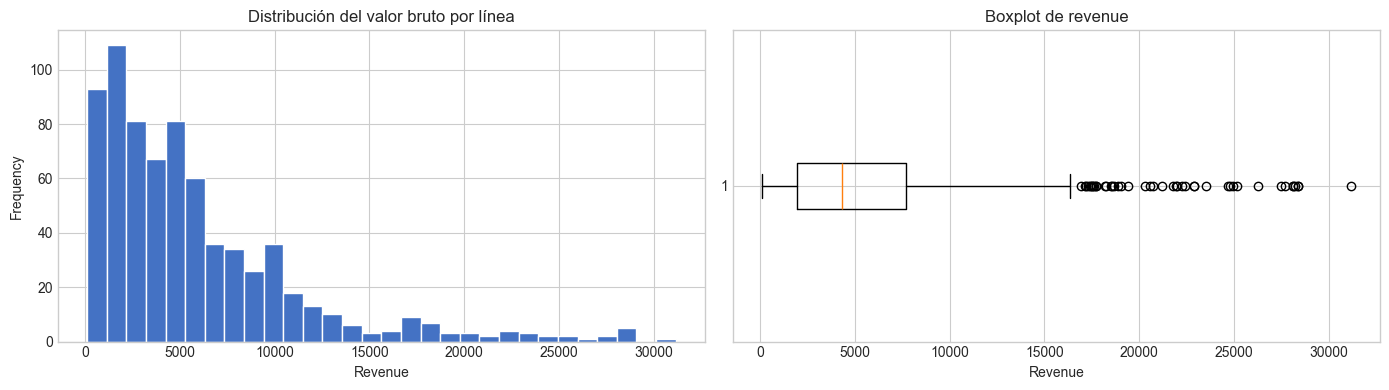

In [33]:
# El análisis trabaja sobre una copia para no alterar la tabla maestra cargada.
analysis_df = df.copy()
analysis_df["revenue_outlier_iqr"] = outlier_masks["revenue"]

revenue_outliers = analysis_df.loc[
    analysis_df["revenue_outlier_iqr"],
    [
        "order_id", "product_name", "category", "country", "channel",
        "unit_price", "quantity", "discount_percentage", "revenue", "order_status",
    ],
].sort_values("revenue", ascending=False)

print(f"Outliers de revenue: {len(revenue_outliers)} líneas")
display(revenue_outliers.head(15))

# Dos vistas estáticas: histograma y caja. No constituyen un dashboard.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

analysis_df["revenue"].dropna().plot.hist(bins=30, ax=axes[0], color="#4472C4", edgecolor="white")
axes[0].set_title("Distribución del valor bruto por línea")
axes[0].set_xlabel("Revenue")

axes[1].boxplot(analysis_df["revenue"].dropna(), vert=False)
axes[1].set_title("Boxplot de revenue")
axes[1].set_xlabel("Revenue")

plt.tight_layout()
plt.show()

## 11. Decisión frente a los outliers

Los outliers se conservan y se monitorean. Eliminarlos reduciría artificialmente el desempeño de un negocio mayorista, donde una línea de gran valor puede ser completamente legítima.

El protocolo aplicado es:

1. marcar el registro;
2. revisar producto, cantidad, precio, cliente, país, canal y estado;
3. contrastar con otras apariciones del mismo producto;
4. comprobar la fuente cuando sea posible;
5. corregir únicamente con evidencia;
6. comparar resultados con y sin extremos como sensibilidad.

La vista sin outliers es una simulación analítica. Nunca reemplaza la tabla maestra ni se presenta como resultado oficial.


In [34]:
# Base oficial: líneas válidas según las reglas de calidad.
valid_lines = analysis_df.loc[analysis_df["valid_sales_flag"]].copy()

# Vista de sensibilidad: excluye temporalmente outliers de revenue.
valid_without_revenue_outliers = valid_lines.loc[~valid_lines["revenue_outlier_iqr"]].copy()

sensitivity = pd.DataFrame({
    "escenario": ["Líneas válidas completas", "Sin outliers IQR de revenue"],
    "lineas": [len(valid_lines), len(valid_without_revenue_outliers)],
    "revenue": [valid_lines["revenue"].sum(), valid_without_revenue_outliers["revenue"].sum()],
    "ticket_medio_linea": [valid_lines["revenue"].mean(), valid_without_revenue_outliers["revenue"].mean()],
})
sensitivity["cambio_revenue_vs_completo_pct"] = (
    sensitivity["revenue"].div(sensitivity.loc[0, "revenue"]).sub(1).mul(100)
)

display(sensitivity)

outlier_share = valid_lines.loc[valid_lines["revenue_outlier_iqr"], "revenue"].sum() / valid_lines["revenue"].sum()
print(f"Los outliers concentran {outlier_share:.2%} del revenue válido.")
print("Conclusión: eliminarlos sin evidencia cambiaría materialmente el resultado.")

,escenario,lineas,revenue,ticket_medio_linea,cambio_revenue_vs_completo_pct
0,Líneas válidas completas,721,"4,174,258.92","5,789.54",0.00
1,Sin outliers IQR de revenue,677,"3,216,948.60","4,751.77",-22.93


Los outliers concentran 22.93% del revenue válido.
Conclusión: eliminarlos sin evidencia cambiaría materialmente el resultado.


## 12. Interpretación del revenue según el estado del pedido

No todo valor registrado representa dinero realizado. Se separan cuatro conceptos:

- **valor bruto solicitado:** todas las líneas válidas;
- **valor cancelado:** pedidos con estado `cancelled`;
- **valor en proceso:** pedidos `confirmed` o `shipped`;
- **ingreso realizado:** pedidos `delivered`.

Esta clasificación evita inflar el desempeño con pedidos cancelados o aún no entregados. En adelante, cualquier cifra de revenue debe indicar expresamente cuál de estas definiciones utiliza.


In [35]:
# Definimos una función clara para clasificar el valor según el estado.
def revenue_stage(status: str) -> str:
    if status == "delivered":
        return "realizado"
    if status == "cancelled":
        return "cancelado"
    if status in {"confirmed", "shipped"}:
        return "en_proceso"
    return "sin_clasificar"


valid_lines["revenue_stage"] = valid_lines["order_status"].map(revenue_stage)

revenue_by_stage = (
    valid_lines.groupby("revenue_stage", as_index=False)
    .agg(
        lineas=("line_number", "count"),
        pedidos=("order_id", "nunique"),
        revenue=("revenue", "sum"),
    )
    .sort_values("revenue", ascending=False)
)
revenue_by_stage["participacion_pct"] = revenue_by_stage["revenue"].div(valid_lines["revenue"].sum()).mul(100)

display(revenue_by_stage)
print(f"Valor bruto solicitado: {valid_lines['revenue'].sum():,.2f}")

,revenue_stage,lineas,pedidos,revenue,participacion_pct
2,realizado,311,93,"1,847,055.29",44.25
1,en_proceso,315,80,"1,793,352.16",42.96
0,cancelado,95,27,"533,851.47",12.79


Valor bruto solicitado: 4,174,258.92


## 13. Perfil descriptivo del negocio

La estadística descriptiva establece qué ocurrió antes de preguntar por qué ocurrió. Se resumen pedidos, líneas, unidades y revenue por estado, siempre respetando la granularidad correspondiente.

Estos resultados sirven como línea base para las secciones de productos y cancelaciones. Una diferencia descriptiva orienta una pregunta, pero todavía no demuestra asociación estadística ni causalidad.


In [36]:
status_summary = (
    analysis_df.groupby("order_status", as_index=False)
    .agg(
        pedidos=("order_id", "nunique"),
        lineas=("line_number", "count"),
        unidades=("quantity", "sum"),
        revenue=("revenue", "sum"),
    )
    .sort_values("pedidos", ascending=False)
)
status_summary["porcentaje_pedidos"] = status_summary["pedidos"].div(analysis_df["order_id"].nunique()).mul(100)

display(status_summary)

,order_status,pedidos,lineas,unidades,revenue,porcentaje_pedidos
2,delivered,93,318,"19,563.00","1,847,055.29",46.50
3,shipped,45,179,"10,890.00","984,221.75",22.50
1,confirmed,35,140,"9,093.00","809,130.41",17.50
0,cancelled,27,96,"5,868.00","533,851.47",13.50


### 13.1 KPIs oficiales y fórmulas

Los KPIs se calculan sobre líneas con `valid_sales_flag=True`, manteniendo todos los estados para describir el volumen registrado. Los pedidos entregados se cuentan una sola vez a nivel pedido. El precio medio efectivo se calcula como `revenue / unidades`, no como promedio simple de precios, para ponderar por cantidad.

In [37]:
valid_sales = analysis_df.loc[analysis_df["valid_sales_flag"]].copy()
orders_status = valid_sales[["order_id", "order_status"]].drop_duplicates("order_id")

def leader_by_revenue(data, column):
    ranking = data.groupby(column, dropna=False)["revenue"].sum().sort_values(ascending=False)
    return ranking.index[0], ranking.iloc[0] / ranking.sum()

leading_country, leading_country_share = leader_by_revenue(valid_sales, "country")
leading_channel, leading_channel_share = leader_by_revenue(valid_sales, "channel")
leading_category, leading_category_share = leader_by_revenue(valid_sales, "category")

kpis = pd.Series({
    "Valor bruto total conocido": valid_sales["revenue"].sum(),
    "Unidades observadas": valid_sales["quantity"].sum(),
    "Pedidos": valid_sales["order_id"].nunique(),
    "Clientes": valid_sales["user_id"].nunique(),
    "Revenue promedio por pedido": valid_sales["revenue"].sum() / valid_sales["order_id"].nunique(),
    "Precio efectivo promedio por unidad": valid_sales["revenue"].sum() / valid_sales["quantity"].sum(),
    "Porcentaje de pedidos entregados": orders_status["order_status"].eq("delivered").mean() * 100,
})

display(kpis.to_frame("valor"))
print(f"País líder: {leading_country} ({leading_country_share:.1%})")
print(f"Canal líder: {leading_channel} ({leading_channel_share:.1%})")
print(f"Categoría líder: {leading_category} ({leading_category_share:.1%})")

,valor
Valor bruto total conocido,"4,174,258.92"
Unidades observadas,"45,414.00"
Pedidos,200.00
Clientes,85.00
Revenue promedio por pedido,"20,871.29"
Precio efectivo promedio por unidad,91.92
Porcentaje de pedidos entregados,46.50


País líder: Colombia (27.0%)
Canal líder: E-commerce B2B (37.8%)
Categoría líder: Footwear (47.8%)


**Conclusión 13.1.** El negocio registra 4,17 millones de valor bruto conocido en 200 pedidos de 85 clientes. Colombia lidera con 27,0%, E-commerce B2B con 37,8% y Footwear con 47,8%. Solo 46,5% de los pedidos figura como entregado; por tanto, `revenue` describe valor bruto registrado, no necesariamente ingreso contablemente realizado.

### 13.2 Evolución mensual y trimestral

La serie cubre un solo año sintético. Las variaciones sirven como alertas descriptivas, pero no prueban tendencia ni estacionalidad. Se comparan revenue, unidades y pedidos para evitar atribuir un cambio únicamente al precio o al volumen.

,year_month,revenue,unidades,pedidos,variacion_revenue_pct
0,2024-01,"409,325.80","3,449.00",12,NaN
1,2024-02,"283,504.37","3,217.00",14,-30.74
2,2024-03,"393,047.60","4,473.00",20,38.64
3,2024-04,"309,816.75","3,169.00",13,-21.18
4,2024-05,"380,854.33","4,053.00",18,22.93
5,2024-06,"281,181.96","3,098.00",14,-26.17
6,2024-07,"306,738.73","3,765.00",17,9.09
7,2024-08,"421,185.91","4,287.00",19,37.31
8,2024-09,"305,204.58","3,661.00",17,-27.54
9,2024-10,"235,084.58","2,440.00",15,-22.97


,year,quarter,revenue,unidades,pedidos,variacion_revenue_pct
0,2024,1,"1,085,877.77","11,139.00",46,NaN
1,2024,2,"971,853.04","10,320.00",45,-10.50
2,2024,3,"1,033,129.22","11,713.00",53,6.31
3,2024,4,"1,083,398.89","12,242.00",56,4.87


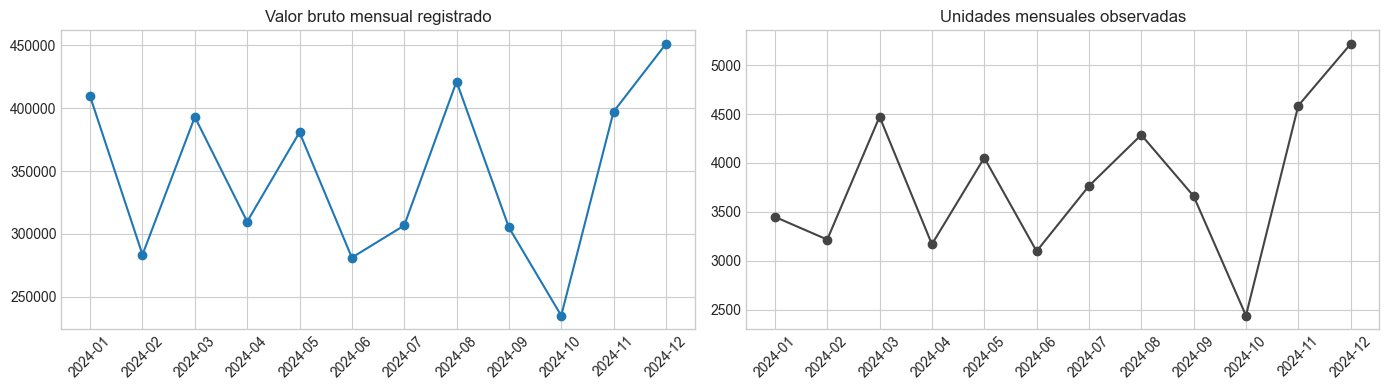

In [38]:
monthly = (
    valid_sales.groupby("year_month", as_index=False)
    .agg(revenue=("revenue", "sum"), unidades=("quantity", "sum"), pedidos=("order_id", "nunique"))
    .sort_values("year_month")
)
monthly["variacion_revenue_pct"] = monthly["revenue"].pct_change().mul(100)

quarterly = (
    valid_sales.groupby(["year", "quarter"], as_index=False)
    .agg(revenue=("revenue", "sum"), unidades=("quantity", "sum"), pedidos=("order_id", "nunique"))
)
quarterly["variacion_revenue_pct"] = quarterly["revenue"].pct_change().mul(100)

display(monthly)
display(quarterly)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(monthly["year_month"], monthly["revenue"], marker="o")
axes[0].set_title("Valor bruto mensual registrado")
axes[0].tick_params(axis="x", rotation=45)
axes[1].plot(monthly["year_month"], monthly["unidades"], marker="o", color="#444444")
axes[1].set_title("Unidades mensuales observadas")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Conclusión 13.2.** El último mes aumenta aproximadamente 13,6% frente al anterior. Esta cifra no debe extrapolarse: con una sola anualidad y datos sintéticos no es posible separar crecimiento, estacionalidad o azar. El control recomendado es ampliar la historia y comparar simultáneamente pedidos, unidades, precio y calendario comercial.

### 13.3 Países, canales, categorías y matriz comercial

Se construyen rankings homogéneos con revenue, unidades, pedidos, clientes, ticket y participación. La matriz país–canal permite ver si el canal líder domina en todos los mercados o si la mezcla comercial cambia por país.

In [39]:
def dimension_summary(data, column):
    result = (
        data.groupby(column, dropna=False, as_index=False)
        .agg(revenue=("revenue", "sum"), unidades=("quantity", "sum"),
             pedidos=("order_id", "nunique"), clientes=("user_id", "nunique"))
        .sort_values("revenue", ascending=False)
    )
    result["participacion_revenue_pct"] = result["revenue"].div(result["revenue"].sum()).mul(100)
    result["revenue_por_pedido"] = result["revenue"].div(result["pedidos"])
    return result

country_summary = dimension_summary(valid_sales, "country")
channel_summary = dimension_summary(valid_sales, "channel")
category_summary = dimension_summary(valid_sales, "category")
price_segment_summary = dimension_summary(valid_sales, "price_segment")

display(country_summary)
display(channel_summary)
display(category_summary)
display(price_segment_summary)

country_channel_matrix = pd.pivot_table(
    valid_sales, index="country", columns="channel", values="revenue", aggfunc="sum", fill_value=0
)
display(country_channel_matrix)

,country,revenue,unidades,pedidos,clientes,participacion_revenue_pct,revenue_por_pedido
2,Colombia,"1,129,080.31","11,457.00",47,19,27.05,"24,022.99"
4,Perú,"785,493.85","9,220.00",41,17,18.82,"19,158.39"
3,México,"765,138.41","8,311.00",36,16,18.33,"21,253.84"
0,Argentina,"763,231.36","8,160.00",37,17,18.28,"20,627.87"
1,Chile,"731,314.99","8,266.00",39,16,17.52,"18,751.67"


,channel,revenue,unidades,pedidos,clientes,participacion_revenue_pct,revenue_por_pedido
2,E-commerce B2B,"1,578,625.47","16,600.00",66,47,37.82,"23,918.57"
0,Direct Sales,"1,305,666.30","14,905.00",70,47,31.28,"18,652.38"
1,Distributor,"1,289,967.15","13,909.00",64,49,30.90,"20,155.74"


,category,revenue,unidades,pedidos,clientes,participacion_revenue_pct,revenue_por_pedido
3,Footwear,"1,997,353.39","11,537.00",122,70,47.85,"16,371.75"
1,Apparel,"801,942.68","10,789.00",118,68,19.21,"6,796.12"
2,Equipment,"727,821.84","11,320.00",108,65,17.44,"6,739.09"
0,Accessories,"647,141.01","11,768.00",113,67,15.50,"5,726.91"


,price_segment,revenue,unidades,pedidos,clientes,participacion_revenue_pct,revenue_por_pedido
1,Medio,"2,558,612.32","28,373.00",182,82,61.30,"14,058.31"
2,Premium,"1,229,513.11","5,349.00",71,49,29.45,"17,317.09"
0,Económico,"386,133.49","11,692.00",127,70,9.25,"3,040.42"


channel,Direct Sales,Distributor,E-commerce B2B
country,,,
Argentina,"207,101.84","239,562.59","316,566.93"
Chile,"264,149.79","179,542.60","287,622.60"
Colombia,"348,894.25","420,516.86","359,669.20"
México,"108,312.06","198,981.32","457,845.03"
Perú,"377,208.36","251,363.78","156,921.71"


**Conclusión 13.3.** La concentración por país es moderada y ningún país supera 30%, mientras Footwear explica casi la mitad del revenue. E-commerce B2B lidera globalmente, pero la matriz revela mezclas distintas por mercado; las acciones de canal deben adaptarse al país y no copiarse de manera uniforme.

### 13.4 Clientes, Pareto y dependencia comercial

La concentración de clientes se calcula a partir del revenue acumulado. Esto muestra cuánto depende el total de las cuentas principales y conecta el análisis descriptivo con la segmentación posterior.

,user_id,customer_name,country,retailer_type,revenue,unidades,pedidos,categorias,participacion_pct,participacion_acumulada_pct
58,65,Josefina Duarte,Argentina,Department Store,"166,591.45","1,610.00",6,4,3.99,3.99
16,18,Delfina Maldonado,Argentina,Sports Chain,"127,102.44","1,172.00",4,4,3.04,7.04
51,57,Margarita Pedroza,México,Superstore,"121,662.57","1,099.00",5,4,2.91,9.95
73,87,Karina Ibarra,Chile,Superstore,"117,584.77","1,380.00",4,4,2.82,12.77
66,77,Jaime Cazares,México,Sports Chain,"114,804.56",865.00,4,4,2.75,15.52
65,74,Jenny Ospina,Colombia,Superstore,"101,065.03","1,281.00",5,4,2.42,17.94
80,95,Andrés Palma,Chile,Independent,"98,997.19","1,158.00",5,4,2.37,20.31
38,43,Arturo Rodríguez,Chile,Sports Chain,"94,761.36","1,141.00",4,4,2.27,22.58
53,59,Francisco Beltrán,Colombia,Superstore,"92,169.31",839.00,3,4,2.21,24.79
18,21,Luis Manuel Venegas,México,Superstore,"89,654.56",898.00,3,4,2.15,26.94


Participación de los 10 clientes principales: 26.9%
Clientes necesarios para alcanzar al menos 80% del revenue: 44 de 85


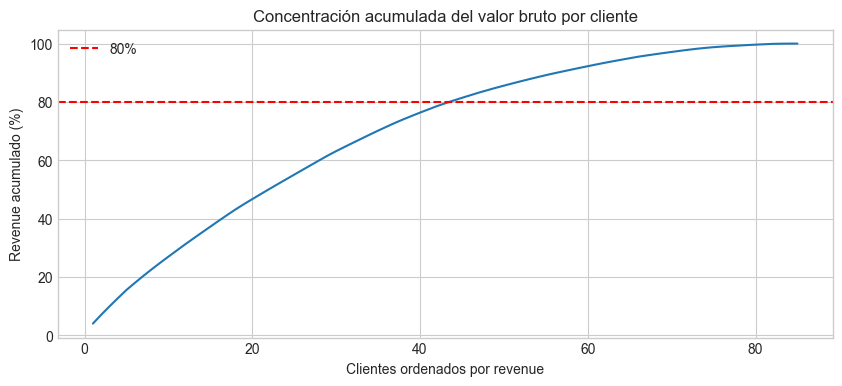

In [40]:
customer_summary = (
    valid_sales.groupby(["user_id", "customer_name", "country", "retailer_type"], as_index=False)
    .agg(revenue=("revenue", "sum"), unidades=("quantity", "sum"),
         pedidos=("order_id", "nunique"), categorias=("category", "nunique"))
    .sort_values("revenue", ascending=False)
)
customer_summary["participacion_pct"] = customer_summary["revenue"].div(customer_summary["revenue"].sum()).mul(100)
customer_summary["participacion_acumulada_pct"] = customer_summary["participacion_pct"].cumsum()

top10_customer_share = customer_summary.head(10)["participacion_pct"].sum()
customers_to_80 = int((customer_summary["participacion_acumulada_pct"] < 80).sum() + 1)

display(customer_summary.head(10))
print(f"Participación de los 10 clientes principales: {top10_customer_share:.1f}%")
print(f"Clientes necesarios para alcanzar al menos 80% del revenue: {customers_to_80} de {len(customer_summary)}")

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(customer_summary) + 1), customer_summary["participacion_acumulada_pct"])
plt.axhline(80, color="red", linestyle="--", label="80%")
plt.title("Concentración acumulada del valor bruto por cliente")
plt.xlabel("Clientes ordenados por revenue")
plt.ylabel("Revenue acumulado (%)")
plt.legend()
plt.show()

**Conclusión 13.4.** Los diez clientes principales representan aproximadamente 26,9% del revenue. No existe un Pareto extremo de pocas cuentas, pero sí una cartera prioritaria que justifica planes de retención sin descuidar el desarrollo de clientes medianos.

### 13.5 Descuentos, calificación e inventario: alcance de la evidencia

Estas variables provienen del producto o la línea, pero no todas representan el estado histórico exacto al momento de la venta. Se resumen sin imputar nulos y se evalúa asociación descriptiva; correlación no implica que el descuento o la calificación hayan causado el resultado.

In [41]:
commercial_attributes = valid_sales[[
    "unit_price", "catalog_price", "discount_percentage", "rating", "inventory", "quantity", "revenue"
]].corr(method="spearman")
display(commercial_attributes)

discount_analysis = (
    valid_sales.assign(
        banda_descuento=pd.cut(
            valid_sales["discount_percentage"],
            bins=[-np.inf, 0, 10, 20, np.inf],
            labels=["0%", ">0–10%", ">10–20%", ">20%"],
        )
    )
    .groupby("banda_descuento", observed=False, as_index=False)
    .agg(lineas=("order_id", "size"), unidades=("quantity", "sum"), revenue=("revenue", "sum"),
         cantidad_mediana=("quantity", "median"), rating_mediano=("rating", "median"))
)
display(discount_analysis)

,unit_price,catalog_price,discount_percentage,rating,inventory,quantity,revenue
unit_price,1.00,1.00,-0.01,0.10,-0.03,0.02,0.70
catalog_price,1.00,1.00,-0.01,0.10,-0.03,0.02,0.70
discount_percentage,-0.01,-0.01,1.00,0.03,0.16,0.07,0.04
rating,0.10,0.10,0.03,1.00,0.05,0.02,0.12
inventory,-0.03,-0.03,0.16,0.05,1.00,-0.01,-0.03
quantity,0.02,0.02,0.07,0.02,-0.01,1.00,0.68
revenue,0.70,0.70,0.04,0.12,-0.03,0.68,1.00


,banda_descuento,lineas,unidades,revenue,cantidad_mediana,rating_mediano
0,0%,0,0.00,0.00,NaN,NaN
1,>0–10%,355,"21,258.00","1,954,043.60",58.00,3.70
2,>10–20%,281,"18,726.00","1,762,408.94",68.00,4.20
3,>20%,85,"5,430.00","457,806.38",66.00,3.40


**Conclusión 13.5.** Los descuentos permiten segmentar y comparar comportamiento, pero la tabla no aclara si `unit_price` ya incorpora el descuento. Tampoco conserva inventario ni rating históricos por fecha. Por eso estas asociaciones son exploratorias y no se recalcula el revenue restando descuentos ni se formula causalidad comercial.

## 14. Top 10 de productos por unidades activas

“Más vendido” se define como mayor cantidad de unidades en pedidos no cancelados y líneas válidas. Se utiliza `quantity`, no `revenue`, para evitar que un producto costoso parezca más demandado únicamente por su precio.

Además de las unidades se revisan revenue, pedidos, países y canales. Un producto con presencia diversificada ofrece una oportunidad comercial más sólida que uno dependiente de un único cliente o mercado.


In [42]:
active_sales = analysis_df.loc[
    analysis_df["valid_sales_flag"] & analysis_df["order_status"].ne("cancelled")
].copy()

product_summary = (
    active_sales.groupby(["product_id", "product_name", "category", "brand", "price_segment"], as_index=False)
    .agg(
        unidades=("quantity", "sum"),
        revenue=("revenue", "sum"),
        pedidos=("order_id", "nunique"),
        precio_promedio=("unit_price", "mean"),
        descuento_promedio=("discount_percentage", "mean"),
        paises=("country", "nunique"),
        canales=("channel", "nunique"),
        inventario_catalogo=("inventory", "first"),
    )
    .sort_values(["unidades", "revenue"], ascending=False)
)

top_10_products = product_summary.head(10).reset_index(drop=True)
top_10_products.index = top_10_products.index + 1
display(top_10_products)

,product_id,product_name,category,brand,price_segment,unidades,revenue,pedidos,precio_promedio,descuento_promedio,paises,canales,inventario_catalogo
1,112,PowerEdge Training Gloves v2,Equipment,PowerEdge,Medio,782.00,"44,566.18",9,56.99,1.30,5,3,136.00
2,93,SportRetail Pro Resistance Bands v3,Equipment,SportRetail Pro,Medio,776.00,"73,021.60",10,94.10,7.40,5,3,184.00
3,79,UrbanSport Headband v4,Accessories,UrbanSport,Medio,741.00,"64,541.10",9,87.10,18.00,3,3,398.00
4,18,CoreFit Slides v3,Footwear,CoreFit,Premium,707.00,"160,177.92",10,226.56,13.50,5,3,398.00
5,45,CoreFit Track Jacket v5,Apparel,CoreFit,Medio,701.00,"58,940.08",9,84.08,3.70,5,3,65.00
6,12,AthletX Training Shoes v2,Footwear,AthletX,Premium,646.00,"143,812.52",9,222.62,13.50,4,3,382.00
7,61,AthletX Sport Backpack v1,Accessories,AthletX,Medio,621.00,"39,632.22",9,63.82,5.60,4,3,101.00
8,100,PowerEdge Jump Rope v5,Equipment,PowerEdge,Económico,605.00,"13,739.55",9,22.71,6.00,4,3,282.00
9,34,UrbanSport Performance T-Shirt v4,Apparel,UrbanSport,Económico,568.00,"21,197.76",8,37.32,24.00,3,3,41.00
10,20,SportRetail Pro Slides v5,Footwear,SportRetail Pro,Medio,561.00,"41,665.47",7,74.27,12.10,5,3,35.00


In [43]:
# Resumimos patrones comunes de los diez líderes.
top_ids = set(top_10_products["product_id"])
top_lines = active_sales.loc[active_sales["product_id"].isin(top_ids)]
other_lines = active_sales.loc[~active_sales["product_id"].isin(top_ids)]

top_commonality = pd.Series({
    "participacion_en_unidades_pct": top_lines["quantity"].sum() / active_sales["quantity"].sum() * 100,
    "participacion_en_revenue_pct": top_lines["revenue"].sum() / active_sales["revenue"].sum() * 100,
    "descuento_promedio_top10": top_lines["discount_percentage"].mean(),
    "descuento_promedio_otros": other_lines["discount_percentage"].mean(),
    "paises_promedio_por_producto_top10": top_10_products["paises"].mean(),
    "productos_top_presentes_en_3_canales": int(top_10_products["canales"].eq(3).sum()),
})

display(top_commonality.to_frame("resultado"))
display(top_10_products["price_segment"].value_counts().rename("productos").to_frame())

print("Lectura: los líderes están diversificados por categoría, marca y precio;")
print("su rasgo más consistente es una cobertura amplia de países y de los tres canales.")

,resultado
participacion_en_unidades_pct,16.96
participacion_en_revenue_pct,18.17
descuento_promedio_top10,10.32
descuento_promedio_otros,11.33
paises_promedio_por_producto_top10,4.30
productos_top_presentes_en_3_canales,10.00


,productos
price_segment,
Medio,6
Premium,2
Económico,2


Lectura: los líderes están diversificados por categoría, marca y precio;
su rasgo más consistente es una cobertura amplia de países y de los tres canales.


## 15. Construcción de la tabla a nivel de pedido

La cancelación ocurre a nivel de pedido. Analizar directamente las 733 líneas daría más peso a los pedidos con muchos productos. Por eso se construye `order_level`, con una fila por `order_id`.

La agregación:

- conserva atributos constantes con `first`;
- suma cantidades y revenue;
- promedia precio, descuento, inventario y rating;
- cuenta líneas y productos;
- identifica categoría y segmento dominantes;
- crea `cancelled_flag`.

Esta tabla es la base común para todas las comparaciones posteriores de cancelación.


In [44]:
def most_frequent(series: pd.Series):
    # Devuelve la moda; si no hay datos devuelve NaN.
    mode = series.dropna().mode()
    return mode.iloc[0] if not mode.empty else np.nan


order_level = (
    analysis_df.groupby("order_id", as_index=False)
    .agg(
        user_id=("user_id", "first"),
        order_date=("order_date", "first"),
        order_status=("order_status", "first"),
        channel=("channel", "first"),
        country=("country", "first"),
        city=("city", "first"),
        retailer_type=("retailer_type", "first"),
        age=("age", "first"),
        line_count=("line_number", "count"),
        total_quantity=("quantity", "sum"),
        order_revenue=("revenue", "sum"),
        avg_unit_price=("unit_price", "mean"),
        avg_discount=("discount_percentage", "mean"),
        avg_inventory=("inventory", "mean"),
        avg_rating=("rating", "mean"),
        dominant_category=("category", most_frequent),
        dominant_price_segment=("price_segment", most_frequent),
    )
)

order_level["cancelled_flag"] = order_level["order_status"].eq("cancelled").astype("int8")
order_level["month"] = order_level["order_date"].dt.month
order_level["quarter"] = order_level["order_date"].dt.quarter

print(f"Pedidos en la tabla agregada: {len(order_level)}")
print(f"Pedidos cancelados: {order_level['cancelled_flag'].sum()}")
print(f"Tasa de cancelación: {order_level['cancelled_flag'].mean():.2%}")
display(order_level.head())

Pedidos en la tabla agregada: 200
Pedidos cancelados: 27
Tasa de cancelación: 13.50%


,order_id,user_id,order_date,order_status,channel,country,city,retailer_type,age,line_count,total_quantity,order_revenue,avg_unit_price,avg_discount,avg_inventory,avg_rating,dominant_category,dominant_price_segment,cancelled_flag,month,quarter
0,1,65,2024-12-03,delivered,Direct Sales,Argentina,Tucumán,Department Store,47,2,130.00,"11,472.32",89.66,8.20,311.50,3.90,Apparel,Medio,0,12,4
1,2,6,2024-06-10,shipped,Distributor,Chile,Valparaíso,Independent,30,2,144.00,"7,584.48",50.58,12.70,113.00,2.90,Apparel,Económico,0,6,2
2,3,87,2024-06-03,delivered,Direct Sales,Chile,Santiago,Superstore,54,5,326.00,"21,361.37",84.74,12.64,217.80,4.24,Accessories,Económico,0,6,2
3,4,45,2024-11-26,shipped,Direct Sales,Perú,Piura,Superstore,42,3,194.00,"10,527.90",54.47,11.00,273.67,4.33,Accessories,Medio,0,11,4
4,5,86,2024-03-03,shipped,Direct Sales,Chile,Concepción,Sports Chain,43,6,376.00,"24,674.31",78.56,13.50,213.17,4.13,Equipment,Económico,0,3,1


### 15.1 Búsqueda de características exclusivas

Se comparan los valores presentes en pedidos cancelados y no cancelados para país, ciudad, canal, minorista, segmento, categoría y producto.

El objetivo es identificar si alguna característica aparece exclusivamente en uno de los grupos. Una exclusividad describe la muestra actual; no implica causalidad ni garantiza repetición en datos futuros.


In [45]:
def exclusive_values(data: pd.DataFrame, variable: str) -> dict:
    # Convertimos cada grupo en un conjunto para comparar presencia y ausencia.
    cancelled_values = set(data.loc[data["cancelled_flag"].eq(1), variable].dropna())
    other_values = set(data.loc[data["cancelled_flag"].eq(0), variable].dropna())

    return {
        "variable": variable,
        "solo_en_cancelados": sorted(cancelled_values - other_values, key=str),
        "solo_en_no_cancelados": sorted(other_values - cancelled_values, key=str),
    }


exclusivity_results = pd.DataFrame([
    exclusive_values(order_level, variable)
    for variable in [
        "country", "city", "channel", "retailer_type",
        "dominant_price_segment", "dominant_category",
    ]
])
display(exclusivity_results)

# Para productos se usa la tabla línea-pedido, porque un pedido puede contener varios productos.
order_product_exclusive = (
    analysis_df[["order_id", "product_id", "product_name", "order_status"]]
    .drop_duplicates(["order_id", "product_id"])
    .copy()
)
cancelled_products = set(order_product_exclusive.loc[
    order_product_exclusive["order_status"].eq("cancelled"), "product_name"
])
other_products = set(order_product_exclusive.loc[
    order_product_exclusive["order_status"].ne("cancelled"), "product_name"
])

print("Productos exclusivos de cancelados:", sorted(cancelled_products - other_products))
print("Cantidad de productos que solo aparecen en no cancelados:", len(other_products - cancelled_products))

,variable,solo_en_cancelados,solo_en_no_cancelados
0,country,[],[]
1,city,[],"[Cartagena, Guadalajara, Lima, Puebla, Tijuana..."
2,channel,[],[]
3,retailer_type,[],[]
4,dominant_price_segment,[],[]
5,dominant_category,[],[]


Productos exclusivos de cancelados: []
Cantidad de productos que solo aparecen en no cancelados: 57


## 16. Descripción de cancelaciones por dimensión

La tasa se calcula como:

`pedidos cancelados / pedidos totales`

Se analiza por país, canal, tipo de minorista, segmento, categoría dominante y periodo. Cada tasa se acompaña de su número de pedidos: un porcentaje alto con muy pocos casos es inestable y no debe priorizarse sin soporte.


In [46]:
def cancellation_rate_table(data: pd.DataFrame, variable: str) -> pd.DataFrame:
    # Resume tamaño, cancelados y tasa para una categoría.
    result = (
        data.groupby(variable, dropna=False)
        .agg(
            pedidos=("order_id", "count"),
            cancelados=("cancelled_flag", "sum"),
            tasa_cancelacion=("cancelled_flag", "mean"),
        )
        .sort_values("tasa_cancelacion", ascending=False)
    )
    result["tasa_cancelacion_pct"] = result["tasa_cancelacion"].mul(100)
    return result


for variable in ["country", "channel", "retailer_type", "dominant_price_segment"]:
    print(f"\nCancelación por {variable}")
    display(cancellation_rate_table(order_level, variable))


Cancelación por country


,pedidos,cancelados,tasa_cancelacion,tasa_cancelacion_pct
country,,,,
Perú,41,7,0.17,17.07
Chile,39,6,0.15,15.38
Colombia,47,7,0.15,14.89
Argentina,37,5,0.14,13.51
México,36,2,0.06,5.56



Cancelación por channel


,pedidos,cancelados,tasa_cancelacion,tasa_cancelacion_pct
channel,,,,
Direct Sales,70,12,0.17,17.14
E-commerce B2B,66,9,0.14,13.64
Distributor,64,6,0.09,9.38



Cancelación por retailer_type


,pedidos,cancelados,tasa_cancelacion,tasa_cancelacion_pct
retailer_type,,,,
Department Store,24,6,0.25,25.00
Online Retailer,34,6,0.18,17.65
Sports Chain,54,7,0.13,12.96
Superstore,45,5,0.11,11.11
Independent,43,3,0.07,6.98



Cancelación por dominant_price_segment


,pedidos,cancelados,tasa_cancelacion,tasa_cancelacion_pct
dominant_price_segment,,,,
Premium,6,1,0.17,16.67
Medio,130,21,0.16,16.15
Económico,64,5,0.08,7.81


## 17. Contraste inferencial de las cancelaciones

La descripción muestra diferencias observadas; la inferencia evalúa si son grandes respecto al tamaño y variabilidad de la muestra. Se utiliza `α = 0.05`:

- `p < 0.05`: evidencia estadística de diferencia o asociación;
- `p ≥ 0.05`: evidencia insuficiente; no demuestra igualdad.

Pruebas aplicadas:

- **Mann–Whitney U:** compara distribuciones numéricas sin exigir normalidad;
- **correlación punto-biserial:** resume dirección e intensidad lineal frente a una variable binaria;
- **diferencia media estandarizada:** cuantifica tamaño de diferencia;
- **chi-cuadrado:** evalúa asociación entre variables categóricas y cancelación;
- **V de Cramér:** mide la intensidad de esa asociación.

Estas pruebas detectan asociaciones; no establecen causas.


In [47]:
def standardized_mean_difference(group_a: pd.Series, group_b: pd.Series) -> float:
    # Diferencia de medias expresada en desviaciones estándar combinadas.
    a = group_a.dropna().astype(float)
    b = group_b.dropna().astype(float)
    pooled_variance = ((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2)
    return (a.mean() - b.mean()) / np.sqrt(pooled_variance) if pooled_variance > 0 else np.nan


numeric_variables = [
    "total_quantity", "order_revenue", "line_count", "avg_unit_price",
    "avg_discount", "avg_inventory", "avg_rating", "age",
]

numeric_results = []

for variable in numeric_variables:
    cancelled = order_level.loc[order_level["cancelled_flag"].eq(1), variable].dropna()
    not_cancelled = order_level.loc[order_level["cancelled_flag"].eq(0), variable].dropna()

    u_statistic, p_value = stats.mannwhitneyu(cancelled, not_cancelled, alternative="two-sided")

    # pointbiserialr necesita pares sin valores nulos.
    paired = order_level[["cancelled_flag", variable]].dropna()
    correlation, correlation_p = stats.pointbiserialr(paired["cancelled_flag"], paired[variable])

    numeric_results.append({
        "variable": variable,
        "media_cancelados": cancelled.mean(),
        "mediana_cancelados": cancelled.median(),
        "media_no_cancelados": not_cancelled.mean(),
        "mediana_no_cancelados": not_cancelled.median(),
        "mann_whitney_p": p_value,
        "correlacion_punto_biserial": correlation,
        "correlacion_p": correlation_p,
        "smd": standardized_mean_difference(cancelled, not_cancelled),
        "evidencia_p_menor_005": p_value < 0.05,
    })

numeric_test_results = pd.DataFrame(numeric_results).sort_values("mann_whitney_p")
display(numeric_test_results)

,variable,media_cancelados,mediana_cancelados,media_no_cancelados,mediana_no_cancelados,mann_whitney_p,correlacion_punto_biserial,correlacion_p,smd,evidencia_p_menor_005
3,avg_unit_price,98.07,97.48,89.45,84.05,0.36,0.08,0.28,0.22,False
5,avg_inventory,251.05,276.00,241.48,239.60,0.42,0.04,0.61,0.11,False
6,avg_rating,3.92,3.97,3.86,3.88,0.66,0.04,0.55,0.12,False
7,age,38.41,39.00,39.18,40.00,0.69,-0.03,0.67,-0.09,False
2,line_count,3.56,4.00,3.68,4.00,0.72,-0.02,0.73,-0.07,False
0,total_quantity,217.33,204.00,228.59,231.00,0.74,-0.03,0.67,-0.09,False
1,order_revenue,"19,772.28","20,766.43","21,042.82","17,162.85",0.88,-0.03,0.68,-0.09,False
4,avg_discount,11.10,11.32,11.24,11.13,0.96,-0.01,0.89,-0.03,False


In [48]:
def cramers_v(contingency: pd.DataFrame, chi2: float) -> float:
    # Tamaño de asociación entre dos variables categóricas.
    n = contingency.to_numpy().sum()
    rows, columns = contingency.shape
    denominator = min(rows - 1, columns - 1)
    return np.sqrt((chi2 / n) / denominator) if n > 0 and denominator > 0 else np.nan


categorical_variables = [
    "country", "channel", "retailer_type", "dominant_price_segment",
    "dominant_category", "month", "quarter",
]

categorical_results = []

for variable in categorical_variables:
    contingency = pd.crosstab(order_level[variable], order_level["cancelled_flag"])

    # La prueba requiere por lo menos dos filas y dos columnas.
    if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
        chi2, p_value, degrees_freedom, expected = stats.chi2_contingency(contingency)
        association = cramers_v(contingency, chi2)
    else:
        chi2, p_value, degrees_freedom, association = np.nan, np.nan, np.nan, np.nan

    categorical_results.append({
        "variable": variable,
        "chi2": chi2,
        "grados_libertad": degrees_freedom,
        "p_value": p_value,
        "cramers_v": association,
        "evidencia_p_menor_005": bool(p_value < 0.05) if pd.notna(p_value) else False,
    })

categorical_test_results = pd.DataFrame(categorical_results).sort_values("p_value")
display(categorical_test_results)

,variable,chi2,grados_libertad,p_value,cramers_v,evidencia_p_menor_005
6,quarter,6.24,3,0.10,0.18,False
5,month,16.45,11,0.13,0.29,False
3,dominant_price_segment,2.61,2,0.27,0.11,False
2,retailer_type,5.02,4,0.29,0.16,False
4,dominant_category,3.04,3,0.39,0.12,False
1,channel,1.73,2,0.42,0.09,False
0,country,2.59,4,0.63,0.11,False


## 18. Cancelación por bandas de cantidad y descuento

Una relación puede ser no lineal y pasar inadvertida en un promedio o correlación. Por eso se crean:

- bandas de cantidad basadas en cuartiles del total por pedido;
- bandas de descuento definidas con límites comerciales.

Para cada banda se muestran pedidos, cancelaciones y tasa. El soporte sigue siendo obligatorio: una tasa extrema basada en pocos pedidos no constituye evidencia estable.


In [49]:
# qcut divide los pedidos en cuatro grupos de tamaño parecido.
order_level["quantity_band"] = pd.qcut(
    order_level["total_quantity"],
    q=4,
    labels=["Q1 - baja", "Q2", "Q3", "Q4 - alta"],
    duplicates="drop",
)

# cut aplica límites definidos por el analista.
order_level["discount_band"] = pd.cut(
    order_level["avg_discount"],
    bins=[-np.inf, 5, 10, 15, 20, 25, np.inf],
    labels=["<=5", "5-10", "10-15", "15-20", "20-25", ">25"],
    include_lowest=True,
)

print("Cancelación por banda de cantidad")
display(cancellation_rate_table(order_level, "quantity_band"))

print("Cancelación por banda de descuento promedio")
display(cancellation_rate_table(order_level, "discount_band"))

Cancelación por banda de cantidad


C:\Users\juanc\AppData\Local\Temp\ipykernel_38680\1250989938.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(variable, dropna=False)


,pedidos,cancelados,tasa_cancelacion,tasa_cancelacion_pct
quantity_band,,,,
Q2,48,8,0.17,16.67
Q3,50,7,0.14,14.00
Q1 - baja,52,7,0.13,13.46
Q4 - alta,50,5,0.10,10.00


Cancelación por banda de descuento promedio


C:\Users\juanc\AppData\Local\Temp\ipykernel_38680\1250989938.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(variable, dropna=False)


,pedidos,cancelados,tasa_cancelacion,tasa_cancelacion_pct
discount_band,,,,
15-20,26,6,0.23,23.08
5-10,61,10,0.16,16.39
10-15,84,9,0.11,10.71
<=5,19,2,0.11,10.53
20-25,10,0,0.00,0.00
>25,0,0,NaN,NaN


## 19. Productos con mayor tasa observada de cancelación

Las tasas por producto pueden ser engañosas cuando el producto aparece pocas veces. Se exige un soporte mínimo de cinco pedidos y se muestran numerador y denominador.

El resultado funciona como lista de priorización para investigar inventario, promesas de entrega, pago o disponibilidad. No permite concluir que el producto sea la causa de la cancelación.


In [50]:
# Primero dejamos una sola aparición de cada producto dentro de cada pedido.
order_product = (
    analysis_df[["order_id", "product_id", "product_name", "category", "order_status"]]
    .drop_duplicates(["order_id", "product_id"])
    .copy()
)
order_product["cancelled_flag"] = order_product["order_status"].eq("cancelled").astype("int8")

product_cancellation = (
    order_product.groupby(["product_id", "product_name", "category"], as_index=False)
    .agg(
        pedidos=("order_id", "nunique"),
        cancelados=("cancelled_flag", "sum"),
        tasa_cancelacion=("cancelled_flag", "mean"),
    )
)

product_cancellation_with_support = (
    product_cancellation.query("pedidos >= 5")
    .sort_values(["tasa_cancelacion", "pedidos"], ascending=[False, False])
)

display(product_cancellation_with_support.head(15))

,product_id,product_name,category,pedidos,cancelados,tasa_cancelacion
7,8,CoreFit Basketball Shoes v3,Footwear,6,3,0.50
81,82,UrbanSport Gym Bag v2,Accessories,9,4,0.44
117,118,UrbanSport Agility Ladder v3,Equipment,7,3,0.43
34,35,AthletX Performance T-Shirt v5,Apparel,5,2,0.40
16,17,AthletX Slides v2,Footwear,8,3,0.38
31,32,PowerEdge Performance T-Shirt v2,Apparel,8,3,0.38
47,48,SpeedMax Compression Tights v3,Apparel,8,3,0.38
93,94,SportRetail Pro Resistance Bands v4,Equipment,8,3,0.38
22,23,SpeedMax Football Boots v3,Footwear,6,2,0.33
108,109,SportRetail Pro Foam Roller v4,Equipment,10,3,0.30


## 20. Modelo oficial del proyecto: segmentación de clientes

### 20.1 Por qué se eligió segmentación y no regresión de revenue

El requerimiento permitía escoger la alternativa de Machine Learning más defendible. Una regresión de `revenue` tendría fuga si usa `quantity` y `unit_price`, porque el objetivo es exactamente su producto; eliminarlas reduce gran parte de la información útil. En cambio, la segmentación responde una necesidad comercial concreta: agrupar minoristas con comportamientos similares para diferenciar retención, reactivación y desarrollo.

La unidad de modelado es el cliente. Se construyen variables RFM ampliadas, ticket, unidades, amplitud y concentración de categorías, participación Premium y preferencias dominantes. Las numéricas monetarias se transforman con `log1p`, se imputan faltantes, se estandarizan y las categóricas se codifican con One-Hot Encoding.

In [51]:
import sys
import tempfile

# Permitimos importar la lógica reusable del repositorio desde cualquier carpeta de inicio.
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.feature_engineering import build_customer_features
from src.model_training import train_segmentation

# Las features se reconstruyen directamente desde la tabla consolidada.
customer_features_rebuilt = build_customer_features(df)
customer_features_saved = pd.read_csv(project_root / "outputs" / "model" / "customer_features.csv")

print(f"Clientes modelados: {len(customer_features_rebuilt)}")
display(customer_features_rebuilt.head())

assert set(customer_features_rebuilt["user_id"]) == set(customer_features_saved["user_id"])
assert len(customer_features_rebuilt) == len(customer_features_saved)
print("Las features reconstruidas corresponden al artefacto oficial guardado.")

Clientes modelados: 85


,user_id,customer_name,country,retailer_type,order_count,total_revenue,average_order_revenue,units,average_days_between_orders,recency_days,category_count,top_category,top_channel,dominant_price_segment,premium_revenue_share,category_concentration_hhi
0,1,Valentino Gomez,Argentina,Sports Chain,2,"37,110.89","18,555.44",407.00,305.00,47,4,Equipment,E-commerce B2B,Medio,0.00,0.37
1,2,Rafael Pérez,Colombia,Sports Chain,4,"88,233.38","22,058.35",968.00,77.67,80,4,Footwear,Direct Sales,Medio,0.25,0.29
2,3,Ángel Osses,Chile,Online Retailer,1,"28,402.80","28,402.80",120.00,NaN,300,1,Footwear,Distributor,Premium,1.00,1.00
3,5,Fernando Valentín,México,Sports Chain,2,"21,447.73","10,723.86",470.00,272.00,44,3,Accessories,E-commerce B2B,Medio,0.00,0.51
4,6,Roxana Jara,Chile,Independent,4,"54,778.34","13,694.58",688.00,67.00,0,3,Apparel,E-commerce B2B,Medio,0.19,0.41


Las features reconstruidas corresponden al artefacto oficial guardado.


### 20.2 Comparación honesta de algoritmos y número de grupos

El código del proyecto compara K-Means, clustering jerárquico y Gaussian Mixture entre 2 y 6 grupos. La métrica principal es silhouette; adicionalmente se exige, cuando es posible, que el segmento menor represente al menos 8% de los clientes para evitar microgrupos poco accionables.

La siguiente celda vuelve a ejecutar la lógica oficial en una carpeta temporal: demuestra reproducibilidad sin sobrescribir los artefactos versionados.

In [52]:
with tempfile.TemporaryDirectory() as temp_model_dir:
    segmentation_rebuilt = train_segmentation(customer_features_rebuilt, Path(temp_model_dir))

comparison_official = pd.read_csv(project_root / "outputs" / "model" / "model_comparison.csv")
metrics_official = json.loads((project_root / "outputs" / "model" / "metrics.json").read_text(encoding="utf-8"))

display(comparison_official.sort_values("silhouette", ascending=False).head(10))
display(pd.Series(metrics_official, name="resultado_oficial").to_frame())

assert segmentation_rebuilt["algorithm"] == metrics_official["selected_model"]
assert segmentation_rebuilt["clusters"] == metrics_official["clusters"]
assert np.isclose(segmentation_rebuilt["silhouette"], metrics_official["silhouette"])
print("La selección del modelo fue reproducida correctamente.")

,algorithm,clusters,silhouette,smallest_cluster_share,inertia
1,Jerárquico,2,0.31,0.15,NaN
2,GaussianMixture,2,0.31,0.18,NaN
0,KMeans,2,0.30,0.20,768.27
5,GaussianMixture,3,0.18,0.14,NaN
9,KMeans,5,0.18,0.12,526.03
6,KMeans,4,0.17,0.09,586.05
12,KMeans,6,0.17,0.04,485.12
13,Jerárquico,6,0.17,0.04,NaN
10,Jerárquico,5,0.17,0.07,NaN
3,KMeans,3,0.16,0.16,657.59


,resultado_oficial
selected_model,Jerárquico
clusters,2
silhouette,0.31
smallest_cluster_share,0.15
pca_explained_variance,"[0.3892307860405368, 0.11971533235293244]"
customers_modeled,85
random_state,42


La selección del modelo fue reproducida correctamente.


### 20.3 Perfiles, interpretación y acciones

El modelo seleccionado es **jerárquico con 2 segmentos** y silhouette de 0,310. Esta separación es moderada: es suficiente para explorar acciones, pero no prueba que existan fronteras naturales perfectas. Los nombres son interpretaciones empresariales de los perfiles medios, no clases observadas.

,cluster,segment,customers,total_revenue,average_revenue,average_orders,average_ticket,average_units,average_recency_days,average_category_count,premium_share,customer_share,predominant_country,predominant_category,recommended_action
0,0,Socios estratégicos,72,"4,080,103.33","56,668.10",2.57,"22,912.67",607.47,102.61,3.46,0.25,0.85,Colombia,Footwear,"Retención ejecutiva, acuerdos de surtido y pla..."
1,1,Reactivación prioritaria,13,"94,155.59","7,242.74",1.15,"6,615.25",128.92,146.85,1.62,0.00,0.15,Chile,Accessories,Campaña de reactivación con contacto comercial...


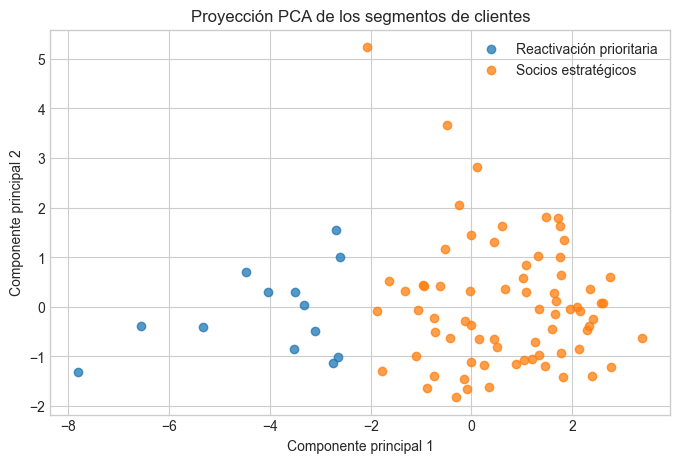

Varianza explicada por dos componentes: 50.9%


In [53]:
segment_profiles = pd.read_csv(project_root / "outputs" / "model" / "segment_profiles.csv")
customer_segments = pd.read_csv(project_root / "outputs" / "model" / "customer_segments.csv")
pca_coordinates = pd.read_csv(project_root / "outputs" / "model" / "pca_coordinates.csv")

display(segment_profiles)

plt.figure(figsize=(8, 5))
for segment, group in pca_coordinates.groupby("segment"):
    plt.scatter(group["pca_1"], group["pca_2"], label=segment, alpha=0.75)
plt.title("Proyección PCA de los segmentos de clientes")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.show()

print(f"Varianza explicada por dos componentes: {sum(metrics_official['pca_explained_variance']):.1%}")

**Conclusión del modelo.** Se identifican 72 **Socios estratégicos** (84,7%), con mayor frecuencia, ticket y amplitud de compra, y 13 clientes de **Reactivación prioritaria** (15,3%), con menor valor y mayor recencia. La PCA explica 50,9% en dos ejes y solo se usa para visualizar. La recomendación es pilotear acciones por segmento durante un trimestre y medir retención, frecuencia, ticket y margen antes de automatizar decisiones.

**Límites:** los datos son sintéticos, cubren un año y no permiten validar estabilidad temporal. Silhouette mide cohesión y separación, no causalidad ni éxito de una campaña.

## 21. Hallazgos integrados y propuestas de mejora

### 1. Categoría tractora y venta cruzada

Footwear aporta 47,8% del revenue. Su disponibilidad tiene un efecto desproporcionado sobre el resultado, pero también crea dependencia de surtido. **Acción:** proteger inventario de referencias líderes y diseñar combinaciones con Accessories; medir incremento de ticket y rotación, no solo ventas brutas.

### 2. Canal escalable con adaptación local

E-commerce B2B concentra 37,8% del revenue, mientras la matriz país–canal muestra mezclas distintas entre mercados. **Acción:** identificar surtidos y tickets ganadores del canal y transferirlos por país mediante pilotos, evitando una política uniforme para toda la región.

### 3. Cartera prioritaria sin dependencia extrema

Los diez clientes principales explican 26,9% del revenue. **Acción:** asignar planes de cuenta a este grupo y usar la segmentación para combinar retención ejecutiva de socios estratégicos con campañas diagnósticas para los 13 clientes de reactivación.

### 4. Revenue operativo todavía expuesto

46,5% de los pedidos está entregado y 13,5% cancelado. Ninguna dimensión analizada explica estadísticamente la cancelación al 5%. **Acción:** crear seguimiento por etapa y recopilar motivo, actor, pago, inventario comprometido y tiempos logísticos antes de construir un modelo causal o predictivo de cancelación.

### 5. Incertidumbre cuantificada, no ocultada

Doce líneas carecen de cantidad. El revenue conocido es 4.174.258,92; el mínimo mayorista aumenta 0,13%, Random Forest 1,64% y el máximo jerárquico 2,26%. Como Random Forest no supera la referencia de mediana, **no se adopta como verdad**. Los escenarios deben publicarse por separado y la fuente original permanecer intacta.

### 6. Extremos plausibles en contexto mayorista

Se detectan 44 líneas de revenue extremo y 18 productos asociados, sin variación histórica de precio para esos productos. **Acción:** conservarlos y monitorearlos; solo corregir con evidencia transaccional adicional. Eliminarlos reduciría ventas mayoristas legítimas.

## 22. Información requerida para aumentar la precisión

Para pasar de descripción a explicación y optimización se necesitan: motivo y actor de cancelación; marcas de tiempo por estado; fallos de pago; inventario disponible al confirmar; fechas prometida y real; incidencias logísticas; precio de lista histórico; definición contable del descuento; promoción o cupón; costo, margen y devoluciones; y varios años de recurrencia del cliente.

Estas variables permitirían estimar demanda y cancelación con validación temporal, distinguir ingreso registrado de realizado, calcular rentabilidad y medir el efecto incremental de promociones o acciones por segmento.

## 23. Reproducción, controles y cierre

### Cómo ejecutar la sustentación

1. Abrir la raíz de `adidas-dest-ac` en Visual Studio Code.
2. Abrir este notebook y seleccionar `J:\python.exe` — Python 3.12.1.
3. Ejecutar **Run All** desde la primera celda.
4. Confirmar que las aserciones de persistencia, calidad, features y selección de modelo terminan sin errores.
5. Si cambia la tabla consolidada, regenerar primero los artefactos construidos del proyecto y después reiniciar el kernel y ejecutar el notebook completo.

### Qué se presenta y qué se excluye

- Se presentan tabla maestra, persistencia, calidad, decisiones de nulos/outliers, indicadores, análisis comercial, inferencia, segmentación, hallazgos y recomendaciones.
- No se consulta la API ni se leen los JSON originales del proveedor.
- No se construye ni se explica el dashboard; este notebook termina justo antes de esa capa de comunicación.
- La tabla maestra no se sobrescribe. Los escenarios viven en columnas nuevas.
- El descuento no se resta del revenue oficial sin definición contable.
- Random Forest es un experimento de imputación; la segmentación jerárquica es el modelo oficial.

### Cierre

El proyecto queda contado como una cadena de evidencia: los formatos reconciliados sostienen la calidad; la calidad delimita los indicadores; los indicadores orientan hipótesis; la inferencia evita conclusiones excesivas; y la segmentación convierte patrones de clientes en acciones que todavía deben validarse mediante pilotos. Esta trazabilidad alinea el notebook con el requerimiento inicial y con los archivos efectivamente construidos en el repositorio.